# **SPARK ON YARN - TIPE 1: PRAPEMROSESAN TERDISTRIBUSI & PELATIHAN TERPUSAT GPU**
## **SKENARIO IRISAN 3 KELAS (NEVUS, MELANOMA, SEBORRHEIC KERATOSIS)**

Notebook ini mengimplementasikan arsitektur hybrid komputasi data besar:
1. **PySpark on YARN:** Digunakan untuk ingesti data dari HDFS dan prapemrosesan citra terdistribusi secara paralel di seluruh worker node.
2. **Centralized GPU Training:** Partisi data yang telah diproses dikumpulkan ke driver untuk melatih arsitektur deep learning ResNet-50 dengan modul Triplet Attention (Baseline AK85) menggunakan akselerasi GPU.

Alur kerja dirancang dengan metodologi CRISP-DM yang ketat dan transparan:
- **Fase 1: Setup Lingkungan Komputasi** (Instalasi Java 11, Hadoop 3.3.6, Spark 3.5.5, SSH)
- **Fase 2: Konfigurasi HDFS** (Penyimpanan data terdistribusi pseudo-distributed)
- **Fase 3: Konfigurasi YARN** (Manajemen resource CPU & RAM untuk cluster worker)
- **Fase 4: Data Understanding & Ingesti HDFS** (Eksplorasi data, audit ukuran, blok HDFS, visualisasi citra asli)
- **Fase 5: Pipeline Preprocessing Terdistribusi** (PySpark RDD, resize 224x224, normalisasi [0, 1], bukti histogram)
- **Fase 6: Data Preparation (Splitting) & Arsitektur Model** (Split Train/Val/Test tanpa kebocoran data, konstruksi ResNet50 + Triplet Attention)
- **Fase 7: Pelatihan Terpusat GPU & Evaluasi Komprehensif** (Training GPU, kurva evaluasi, confusion matrix, classification report, logging)

In [1]:
!rm -f /kaggle/working/riset_kanker_kulit/results.csv

# **FASE 1 - Set up Env**
1. Deteksi Lingkungan & Mount Storage (Mendukung Kaggle & Google Colab)
2. Konfigurasi Skenario dan Path Kerja
3. Generate dan Jalankan `setup_env.sh` (Java 11, Hadoop, Spark, SSH)
4. Set Environment Variables
5. Verifikasi Instalasi Dasar

### **1. Deteksi Lingkungan & Mount Storage**
Notebook secara otomatis mendeteksi apakah dijalankan di Google Colab atau Kaggle. Jika di Colab, Google Drive dimuat untuk penyimpanan cache.

In [2]:
from pathlib import Path
import os
import sys

# Deteksi lingkungan eksekusi secara otomatis
if Path("/kaggle/working").exists():
    ENV_NAME = "kaggle"
    INSTALL_DIR = Path("/kaggle/working")
    PROJECT_DIR = INSTALL_DIR / "riset_kanker_kulit"
    print("Terdeteksi lingkungan: Kaggle Notebook")
else:
    ENV_NAME = "colab"
    INSTALL_DIR = Path("/content")
    PROJECT_DIR = Path("/content/drive/MyDrive/riset_kanker_kulit")
    print("Terdeteksi lingkungan: Google Colab")
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Peringatan saat mount drive:", e)

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Direktori kerja utama: {PROJECT_DIR}")

Terdeteksi lingkungan: Kaggle Notebook
Direktori kerja utama: /kaggle/working/riset_kanker_kulit


### **2. Konfigurasi Skenario dan Path**
Pengaturan skenario eksperimen meliputi jumlah worker YARN, jumlah partisi RDD, serta jumlah epoch pelatihan.

In [3]:
# Konfigurasi skenario eksperimen
NUM_WORKERS = 2
NUM_PARTITIONS = 2
EPOCHS = 15
SCENARIO_TYPE = "irisan"

SCENARIO_NAME = f"{SCENARIO_TYPE}_{NUM_WORKERS}W{NUM_PARTITIONS}P"

# Versi komponen sistem
HADOOP_VERSION = "3.3.6"
SPARK_VERSION = "3.5.5"
SPARK_HADOOP_PROFILE = "hadoop3"

SSH_PORT = 2222

# Path instalasi lokal (ephemeral per sesi)
HADOOP_HOME = INSTALL_DIR / "hadoop"
SPARK_HOME = INSTALL_DIR / "spark"
HADOOP_CONF_DIR = HADOOP_HOME / "etc" / "hadoop"

# HDFS dipindah keluar dari /kaggle/working (kuota output ~20GB) ke /kaggle/temp
# (scratch non-persisten, jauh lebih besar) — supaya cukup untuk dataset 18+ GB.
# Di Colab tetap seperti semula.
DATA_DIR = Path("/kaggle/temp/hadoop_data") if ENV_NAME == "kaggle" else INSTALL_DIR / "hadoop_data"
NAMENODE_DIR = DATA_DIR / "namenode"
DATANODE_DIR = DATA_DIR / "datanode"

HDFS_WORKDIR = f"/user/skincancer/{SCENARIO_TYPE}"

# Direktori cache dan script
CACHE_DIR = PROJECT_DIR / "cache"
SCRIPT_DIR = PROJECT_DIR / "scripts"
SETUP_SCRIPT_PATH = SCRIPT_DIR / "setup_env.sh"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Skenario: {SCENARIO_NAME}")
print(f"Hadoop Home: {HADOOP_HOME}")
print(f"Spark Home: {SPARK_HOME}")
print(f"HDFS Workdir: {HDFS_WORKDIR}")

Skenario: irisan_2W2P
Hadoop Home: /kaggle/working/hadoop
Spark Home: /kaggle/working/spark
HDFS Workdir: /user/skincancer/irisan


### **3. Generate dan Jalankan `setup_env.sh`**
Skrip bash ini bersifat idempoten dan mengunduh Java 11, Hadoop 3.3.6, Spark 3.5.5, serta mengonfigurasi SSH tanpa password untuk komunikasi master-worker di localhost.

In [4]:
SETUP_SCRIPT = f"""#!/bin/bash
set -e

HADOOP_VERSION="{HADOOP_VERSION}"
SPARK_VERSION="{SPARK_VERSION}"
SPARK_HADOOP_PROFILE="{SPARK_HADOOP_PROFILE}"
SSH_PORT="{SSH_PORT}"

INSTALL_DIR="{INSTALL_DIR}"
HADOOP_HOME="{HADOOP_HOME}"
SPARK_HOME="{SPARK_HOME}"
CACHE_DIR="{CACHE_DIR}"

HADOOP_ARCHIVE="hadoop-${{HADOOP_VERSION}}.tar.gz"
SPARK_ARCHIVE="spark-${{SPARK_VERSION}}-bin-${{SPARK_HADOOP_PROFILE}}.tgz"

HADOOP_URL="https://archive.apache.org/dist/hadoop/common/hadoop-${{HADOOP_VERSION}}/${{HADOOP_ARCHIVE}}"
SPARK_URL="https://archive.apache.org/dist/spark/spark-${{SPARK_VERSION}}/${{SPARK_ARCHIVE}}"

mkdir -p "${{CACHE_DIR}}"

fetch_archive() {{
    local archive_name="$1"
    local url="$2"
    local local_path="${{INSTALL_DIR}}/${{archive_name}}"
    local cache_path="${{CACHE_DIR}}/${{archive_name}}"

    if [ -f "${{local_path}}" ]; then
        return 0
    fi

    if [ -f "${{cache_path}}" ]; then
        echo "Menggunakan cache arsip dari storage persisten: ${{archive_name}}"
        cp "${{cache_path}}" "${{local_path}}"
    else
        echo "Mengunduh ${{archive_name}}..."
        if command -v aria2c >/dev/null 2>&1; then
            aria2c -x 8 -s 8 -q -d "${{INSTALL_DIR}}" -o "${{archive_name}}" "${{url}}"
        else
            wget -q "${{url}}" -O "${{local_path}}"
        fi
        if [ -d "${{CACHE_DIR}}" ]; then
            cp "${{local_path}}" "${{cache_path}}" || true
        fi
    fi
}}

echo "=== 1. Memeriksa Java 11 ==="
dpkg -s openjdk-11-jdk-headless >/dev/null 2>&1 || {{
    apt-get update -qq
    apt-get install -y -qq openjdk-11-jdk-headless
}}

echo "=== 2. Memeriksa Hadoop ${{HADOOP_VERSION}} ==="
if [ ! -d "${{HADOOP_HOME}}" ]; then
    fetch_archive "${{HADOOP_ARCHIVE}}" "${{HADOOP_URL}}"
    tar -xzf "${{INSTALL_DIR}}/${{HADOOP_ARCHIVE}}" -C "${{INSTALL_DIR}}"
    mv "${{INSTALL_DIR}}/hadoop-${{HADOOP_VERSION}}" "${{HADOOP_HOME}}"
fi

echo "=== 3. Memeriksa Spark ${{SPARK_VERSION}} ==="
if [ ! -d "${{SPARK_HOME}}" ]; then
    fetch_archive "${{SPARK_ARCHIVE}}" "${{SPARK_URL}}"
    tar -xzf "${{INSTALL_DIR}}/${{SPARK_ARCHIVE}}" -C "${{INSTALL_DIR}}"
    mv "${{INSTALL_DIR}}/spark-${{SPARK_VERSION}}-bin-${{SPARK_HADOOP_PROFILE}}" "${{SPARK_HOME}}"
fi

echo "=== 4. Konfigurasi SSH Localhost ==="
dpkg -s openssh-server >/dev/null 2>&1 || {{
    apt-get update -qq
    apt-get install -y -qq openssh-server openssh-client
}}
mkdir -p /var/run/sshd ~/.ssh

ssh-keygen -A

[ -f ~/.ssh/id_rsa ] || ssh-keygen -t rsa -P '' -f ~/.ssh/id_rsa -q
touch ~/.ssh/authorized_keys
grep -qxF "$(cat ~/.ssh/id_rsa.pub)" ~/.ssh/authorized_keys || cat ~/.ssh/id_rsa.pub >> ~/.ssh/authorized_keys
chmod 700 ~/.ssh
chmod 600 ~/.ssh/authorized_keys

# Set port SSH secara idempoten: hapus semua direktif Port lama, lalu tulis satu baris baru.
# (Pendekatan sed berantai sebelumnya menghasilkan "Port 222222" karena "Port 2222"
#  masih cocok dengan pola "Port 22".)
sed -i -E '/^[[:space:]]*#?[[:space:]]*Port[[:space:]]+[0-9]+/d' /etc/ssh/sshd_config
echo "Port ${{SSH_PORT}}" >> /etc/ssh/sshd_config
grep -n "^Port " /etc/ssh/sshd_config

port_is_listening() {{
    (ss -ltn 2>/dev/null || netstat -ltn 2>/dev/null) | grep -q ":${{SSH_PORT}}[[:space:]]"
}}

service ssh restart || true
sleep 2

if ! port_is_listening; then
    echo "service ssh tidak berhasil, menjalankan sshd secara langsung..."
    pkill -f "sshd" || true
    sleep 1
    /usr/sbin/sshd -p "${{SSH_PORT}}"
    sleep 2
fi

if ! port_is_listening; then
    echo "FATAL: sshd tidak listening di port ${{SSH_PORT}}"
    exit 1
fi

echo "Setup lingkungan selesai: Java 11, Hadoop, Spark, dan SSH (port ${{SSH_PORT}}) siap."
"""

SETUP_SCRIPT_PATH.write_text(SETUP_SCRIPT)
SETUP_SCRIPT_PATH.chmod(0o755)
print(f"Skrip setup berhasil dibuat: {SETUP_SCRIPT_PATH}")

Skrip setup berhasil dibuat: /kaggle/working/riset_kanker_kulit/scripts/setup_env.sh


In [5]:
!bash "{SETUP_SCRIPT_PATH}" 

=== 1. Memeriksa Java 11 ===
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.32+9-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.32+9-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.32+9-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.32+9-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.32+9-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/

### **4. Set Environment Variables**
Menentukan path `JAVA_HOME`, `HADOOP_HOME`, dan `SPARK_HOME` secara dinamis pada environment runtime Python.

In [6]:
import os
import subprocess

def resolve_java_home() -> str:
    candidate = Path("/usr/lib/jvm/java-11-openjdk-amd64")
    if candidate.exists():
        return str(candidate)

    alternatives = subprocess.run(
        ["update-alternatives", "--list", "java"], capture_output=True, text=True
    ).stdout.splitlines()
    for path in alternatives:
        if "java-11" in path:
            return str(Path(path).parent.parent)

    which_java = subprocess.run(
        ["which", "java"], capture_output=True, text=True, check=True
    ).stdout.strip()
    real_java = subprocess.run(
        ["readlink", "-f", which_java], capture_output=True, text=True, check=True
    ).stdout.strip()
    return str(Path(real_java).parent.parent)

os.environ["JAVA_HOME"] = resolve_java_home()
os.environ["HADOOP_HOME"] = str(HADOOP_HOME)
os.environ["SPARK_HOME"] = str(SPARK_HOME)
os.environ["HADOOP_CONF_DIR"] = str(HADOOP_CONF_DIR)

# Ditambahkan, bukan ditimpa, agar path pustaka CUDA milik runtime tidak hilang
_existing_ld = os.environ.get("LD_LIBRARY_PATH", "")
_hadoop_native = str(HADOOP_HOME / "lib" / "native")
os.environ["LD_LIBRARY_PATH"] = (
    f"{_hadoop_native}:{_existing_ld}" if _existing_ld else _hadoop_native
)

# Pastikan driver dan executor PySpark memakai interpreter Python yang sama
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

os.environ["PATH"] = ":".join([
    f"{os.environ['JAVA_HOME']}/bin",
    f"{os.environ['HADOOP_HOME']}/bin",
    f"{os.environ['HADOOP_HOME']}/sbin",
    f"{os.environ['SPARK_HOME']}/bin",
    f"{os.environ['SPARK_HOME']}/sbin",
    os.environ["PATH"],
])

print(f"JAVA_HOME      = {os.environ['JAVA_HOME']}")
print(f"HADOOP_HOME    = {os.environ['HADOOP_HOME']}")
print(f"SPARK_HOME     = {os.environ['SPARK_HOME']}")
print(f"PYSPARK_PYTHON = {os.environ['PYSPARK_PYTHON']}")

JAVA_HOME      = /usr/lib/jvm/java-11-openjdk-amd64
HADOOP_HOME    = /kaggle/working/hadoop
SPARK_HOME     = /kaggle/working/spark
PYSPARK_PYTHON = /usr/bin/python3


### **5. Verifikasi Instalasi Dasar**
Memastikan binary Java, Hadoop, Spark, dan konektivitas SSH localhost berjalan normal.

In [7]:
!java -version
!$HADOOP_HOME/bin/hadoop version
!$SPARK_HOME/bin/spark-submit --version
!ssh -o StrictHostKeyChecking=no -p {SSH_PORT} localhost "echo SSH connection OK" 

openjdk version "11.0.32" 2026-07-21
OpenJDK Runtime Environment (build 11.0.32+9-post-1ubuntu1-22.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 11.0.32+9-post-1ubuntu1-22.04-Ubuntu, mixed mode, sharing)
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /kaggle/working/hadoop/share/hadoop/common/hadoop-common-3.3.6.jar
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /___/ .__/\_,_/_/ /_/\_\   version 3.5.5
      /_/
                        
Using Scala version 2.12.18, OpenJDK 64-Bit Server VM, 11.0.32
Branch HEAD
Compiled by user ubuntu on 2025-02-23T20:30:46Z
Revision 7c29c664cdc9321205a98a14858aaf8daaa19db2
Url https://github.com/apache/spark
Type --help for more information.
SSH connec

# **FASE 2 - Konfigurasi HDFS**
6. Menulis `core-site.xml` (Pengalamatan default NameNode)
7. Menulis `hdfs-site.xml` & Daftarkan `JAVA_HOME` ke `hadoop-env.sh`
8. Format NameNode (Idempotent)
9. Menjalankan HDFS Daemons & Verifikasi JPS
10. Membuat Direktori Kerja HDFS

### **6. `core-site.xml`**
Mengarahkan default filesystem HDFS ke port 9000 localhost.

In [8]:
CORE_SITE = """<?xml version="1.0" encoding="UTF-8"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>fs.defaultFS</name>
        <value>hdfs://localhost:9000</value>
    </property>
</configuration>
"""

core_site_path = HADOOP_CONF_DIR / "core-site.xml"
core_site_path.write_text(CORE_SITE)
print(f"Tersimpan: {core_site_path}")

Tersimpan: /kaggle/working/hadoop/etc/hadoop/core-site.xml


### **7. `hdfs-site.xml` dan `hadoop-env.sh`**
Mengonfigurasi direktori penyimpanan fisik blok data NameNode & DataNode, serta mematikan pengecekan permission agar tidak terjadi kendala akses.

In [9]:
NAMENODE_DIR.mkdir(parents=True, exist_ok=True)
DATANODE_DIR.mkdir(parents=True, exist_ok=True)

HDFS_SITE = f"""<?xml version="1.0" encoding="UTF-8"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>dfs.replication</name>
        <value>1</value>
    </property>
    <property>
        <name>dfs.namenode.name.dir</name>
        <value>file://{NAMENODE_DIR}</value>
    </property>
    <property>
        <name>dfs.datanode.data.dir</name>
        <value>file://{DATANODE_DIR}</value>
    </property>
    <property>
        <name>dfs.permissions.enabled</name>
        <value>false</value>
    </property>
    <property>
        <name>dfs.namenode.secondary.http-address</name>
        <value>localhost:9868</value>
    </property>
</configuration>
"""

hdfs_site_path = HADOOP_CONF_DIR / "hdfs-site.xml"
hdfs_site_path.write_text(HDFS_SITE)
print(f"Tersimpan: {hdfs_site_path}")

hadoop_env_path = HADOOP_CONF_DIR / "hadoop-env.sh"

env_exports = {
    "JAVA_HOME": os.environ["JAVA_HOME"],
    "HADOOP_SSH_OPTS": f"-p {SSH_PORT}",
    "HDFS_NAMENODE_USER": "root",
    "HDFS_DATANODE_USER": "root",
    "HDFS_SECONDARYNAMENODE_USER": "root",
    "YARN_RESOURCEMANAGER_USER": "root",
    "YARN_NODEMANAGER_USER": "root",
}

lines = [
    line for line in hadoop_env_path.read_text().splitlines()
    if not any(line.strip().startswith(f"export {key}=") for key in env_exports)
]
for key, value in env_exports.items():
    lines.append(f'export {key}="{value}"')

hadoop_env_path.write_text("\n".join(lines) + "\n")
print("hadoop-env.sh berhasil diperbarui.")

Tersimpan: /kaggle/working/hadoop/etc/hadoop/hdfs-site.xml
hadoop-env.sh berhasil diperbarui.


### **8. Format NameNode**
Memformat filesystem NameNode jika belum pernah diinisialisasi pada sesi ini.

In [10]:
version_file = NAMENODE_DIR / "current" / "VERSION"

if version_file.exists():
    print("NameNode sudah pernah diformat sebelumnya, langkah ini dilewati.")
else:
    print("Memformat NameNode...")
    result = subprocess.run(
        [str(HADOOP_HOME / "bin" / "hdfs"), "namenode", "-format", "-force"],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("Format NameNode gagal")
    print("NameNode berhasil diformat.")

Memformat NameNode...
NameNode berhasil diformat.


### **9. Start HDFS dan Verifikasi**
Menjalankan daemon NameNode, DataNode, dan SecondaryNameNode serta memvalidasi ketersediaannya lewat Java Process Status (JPS).

In [11]:
!$HADOOP_HOME/sbin/start-dfs.sh

# NameNode berada dalam safemode ~30 detik setelah start; tunggu sampai keluar
# agar `hdfs dfs -mkdir` pada langkah berikutnya tidak gagal saat Run All.
!$HADOOP_HOME/bin/hdfs dfsadmin -safemode wait

Starting namenodes on [localhost]
Starting datanodes
Starting secondary namenodes [localhost]
Safe mode is OFF


In [12]:
def check_jps(expected_processes):
    output = subprocess.run(["jps"], capture_output=True, text=True).stdout
    print("Daftar proses Java (jps):")
    print(output)
    all_ok = True
    for name in expected_processes:
        status = "BERJALAN (OK)" if name in output else "TIDAK DITEMUKAN (MISSING)"
        print(f"  - {name}: {status}")
        if name not in output:
            all_ok = False
    return all_ok

assert check_jps(["NameNode", "DataNode"]), \
    "Daemon HDFS tidak lengkap. Hentikan eksekusi dan periksa $HADOOP_HOME/logs."

Daftar proses Java (jps):
2256 NameNode
2368 DataNode
2579 SecondaryNameNode
2777 Jps

  - NameNode: BERJALAN (OK)
  - DataNode: BERJALAN (OK)


### **10. Buat Direktori Kerja di HDFS**
Membuat path kerja HDFS dan memeriksa kapasitas cluster.

In [13]:
!hdfs dfs -mkdir -p {HDFS_WORKDIR}
!hdfs dfs -ls -R /user/skincancer
!hdfs dfsadmin -report

drwxr-xr-x   - root supergroup          0 2026-09-21 04:49 /user/skincancer/irisan
Configured Capacity: 8656922775552 (7.87 TB)
Present Capacity: 1099862716416 (1.00 TB)
DFS Remaining: 1099862691840 (1.00 TB)
DFS Used: 24576 (24 KB)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

-------------------------------------------------
Live datanodes (1):

Name: 127.0.0.1:9866 (localhost)
Hostname: ec583e91b36f
Decommission Status : Normal
Configured Capacity: 8656922775552 (7.87 TB)
DFS Used: 24576 (24 KB)
Non DFS Used: 7557043281920 (6.87 TB)
DFS Remaining: 1099862691840 (1.00

# **FASE 3 - Konfigurasi YARN**
11. Cek Kapasitas Aktual Lingkungan (CPU & RAM)
12. Hitung Alokasi Resource YARN dan Executor Dinamis
13. Menulis `yarn-site.xml`
14. Menulis `mapred-site.xml`
15. Menjalankan YARN Daemons & Verifikasi
16. Stage Spark Jars ke HDFS (`spark-libs.zip`)
17. Menulis `spark-defaults.conf`
18. Verifikasi Submit Job ke YARN (`SparkPi`)

### **11. Cek Kapasitas Aktual Lingkungan**
Memeriksa jumlah core CPU fisik dan memori RAM aktual yang tersedia pada container runtime.

In [14]:
!nproc
!free -h

4
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.9Gi        17Gi       1.0Mi        12Gi        29Gi
Swap:             0B          0B          0B


### **12. Hitung Alokasi Resource YARN dan Executor**
Mengalokasikan memori NodeManager dan container executor secara dinamis agar aman dari pembatalan memori virtual oleh YARN.

In [15]:
import subprocess

cpu_count = int(subprocess.run(["nproc"], capture_output=True, text=True).stdout.strip())
free_lines = subprocess.run(["free", "-m"], capture_output=True, text=True).stdout.splitlines()
total_mem_mb = int(free_lines[1].split()[1])

# Sisakan RAM 2GB untuk OS, kernel Jupyter, dan proses GPU/Driver
RESERVED_MEM_MB = 2048

# Skenario penelitian: jumlah worker ∈ {2, 8}. Ukuran SETIAP executor DIKUNCI sama di
# semua skenario; yang berubah hanya JUMLAH executor. Kapasitas NodeManager juga dikunci
# pada kebutuhan skenario terbesar (8 worker), jadi 2W dan 8W berjalan di klaster identik.
MAX_WORKERS_PLANNED = 8
EXECUTOR_CONTAINER_MB = 1536            # kelipatan yarn.scheduler.minimum-allocation-mb (512)
EXECUTOR_MEMORY_OVERHEAD_MB = 384
EXECUTOR_MEMORY_MB = EXECUTOR_CONTAINER_MB - EXECUTOR_MEMORY_OVERHEAD_MB   # 1152 MB heap
EXECUTOR_CORES = 1
AM_CONTAINER_MB = 1024                  # ApplicationMaster mode client: 512m + 384m overhead, dibulatkan YARN
NM_SLACK_MB = 1024

YARN_NM_MEMORY_MB = MAX_WORKERS_PLANNED * EXECUTOR_CONTAINER_MB + AM_CONTAINER_MB + NM_SLACK_MB  # 14336
YARN_NM_VCORES = max(cpu_count, MAX_WORKERS_PLANNED)

assert NUM_WORKERS <= MAX_WORKERS_PLANNED, "NUM_WORKERS melebihi MAX_WORKERS_PLANNED."
assert total_mem_mb - RESERVED_MEM_MB >= YARN_NM_MEMORY_MB, (
    f"RAM runtime ({total_mem_mb} MB) tidak cukup untuk NodeManager {YARN_NM_MEMORY_MB} MB."
)

if cpu_count < NUM_WORKERS:
    print(f"PERINGATAN: hanya {cpu_count} core fisik untuk {NUM_WORKERS} executor (1 core/executor). "
          f"Speedup akan dibatasi kontensi CPU, bukan murni efek paralelisasi. Catat nilai nproc di laporan.")

_needed = NUM_WORKERS * EXECUTOR_CONTAINER_MB + AM_CONTAINER_MB
print(f"CPU Fisik: {cpu_count}, RAM Total: {total_mem_mb} MB")
print(f"YARN NodeManager: {YARN_NM_MEMORY_MB} MB, {YARN_NM_VCORES} vcores")
print(f"Alokasi per Executor: {EXECUTOR_MEMORY_MB} MB (+ {EXECUTOR_MEMORY_OVERHEAD_MB} MB overhead), {EXECUTOR_CORES} core")
print(f"Kebutuhan skenario {NUM_WORKERS}W: {_needed} MB (termasuk AM {AM_CONTAINER_MB} MB) dari {YARN_NM_MEMORY_MB} MB")

CPU Fisik: 4, RAM Total: 32100 MB
YARN NodeManager: 14336 MB, 8 vcores
Alokasi per Executor: 1152 MB (+ 384 MB overhead), 1 core
Kebutuhan skenario 2W: 4096 MB (termasuk AM 1024 MB) dari 14336 MB


### **13. `yarn-site.xml`**
Konfigurasi NodeManager dengan menonaktifkan pengecekan virtual memory (`vmem-check-enabled = false`) agar container tidak dimatikan paksa di lingkungan virtual.

In [16]:
# yarn.resourcemanager.hostname WAJIB diset eksplisit. Tanpa ini, defaultnya
# "0.0.0.0" dan yarn.resourcemanager.address ikut default ke "0.0.0.0:8032" --
# alamat bind (dengarkan di semua interface), bukan alamat yang bisa dituju
# klien. Akibatnya spark-submit gagal dengan "Connection refused" /
# "Your endpoint configuration is wrong" walau proses ResourceManager hidup.
YARN_SITE = f"""<?xml version="1.0"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>yarn.resourcemanager.hostname</name>
        <value>localhost</value>
    </property>
    <property>
        <name>yarn.nodemanager.aux-services</name>
        <value>mapreduce_shuffle</value>
    </property>
    <property>
        <name>yarn.nodemanager.aux-services.mapreduce.shuffle.class</name>
        <value>org.apache.hadoop.mapred.ShuffleHandler</value>
    </property>
    <property>
        <name>yarn.nodemanager.resource.memory-mb</name>
        <value>{YARN_NM_MEMORY_MB}</value>
    </property>
    <property>
        <name>yarn.nodemanager.resource.cpu-vcores</name>
        <value>{YARN_NM_VCORES}</value>
    </property>
    <property>
        <name>yarn.nodemanager.vmem-check-enabled</name>
        <value>false</value>
    </property>
    <property>
        <name>yarn.nodemanager.pmem-check-enabled</name>
        <value>false</value>
    </property>
    <property>
        <name>yarn.nodemanager.disk-health-checker.enable</name>
        <value>false</value>
    </property>
    <property>
        <name>yarn.nodemanager.disk-health-checker.max-disk-utilization-per-disk-percentage</name>
        <value>99.0</value>
    </property>
    <property>
        <name>yarn.scheduler.minimum-allocation-mb</name>
        <value>512</value>
    </property>
    <property>
        <name>yarn.scheduler.maximum-allocation-mb</name>
        <value>{YARN_NM_MEMORY_MB}</value>
    </property>
    <property>
        <name>yarn.scheduler.maximum-allocation-vcores</name>
        <value>{YARN_NM_VCORES}</value>
    </property>
</configuration>
"""

yarn_site_path = HADOOP_CONF_DIR / "yarn-site.xml"
yarn_site_path.write_text(YARN_SITE)
print(f"Tersimpan: {yarn_site_path}")


Tersimpan: /kaggle/working/hadoop/etc/hadoop/yarn-site.xml


### **14. `mapred-site.xml`**
Mengarahkan framework eksekusi MapReduce ke YARN.

In [17]:
MAPRED_SITE = """<?xml version="1.0"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>mapreduce.framework.name</name>
        <value>yarn</value>
    </property>
</configuration>
"""

mapred_site_path = HADOOP_CONF_DIR / "mapred-site.xml"
mapred_site_path.write_text(MAPRED_SITE)
print(f"Tersimpan: {mapred_site_path}")

Tersimpan: /kaggle/working/hadoop/etc/hadoop/mapred-site.xml


### **15. Start YARN dan Verifikasi**
Menjalankan ResourceManager dan NodeManager, lalu memvalidasi status proses Java.

In [18]:
!$HADOOP_HOME/sbin/stop-yarn.sh
!rm -f /tmp/hadoop-*-resourcemanager.pid /tmp/hadoop-*-nodemanager.pid
!setsid $HADOOP_HOME/sbin/start-yarn.sh < /dev/null > /tmp/start-yarn.log 2>&1

import time
time.sleep(8)
print("=== /tmp/start-yarn.log ===")
!cat /tmp/start-yarn.log

Stopping nodemanagers
Stopping resourcemanager
=== /tmp/start-yarn.log ===
Starting resourcemanager
Starting nodemanagers


In [19]:
assert check_jps(["ResourceManager", "NodeManager"]), \
    "Daemon YARN tidak lengkap. Hentikan eksekusi dan periksa $HADOOP_HOME/logs."

Daftar proses Java (jps):
2256 NameNode
2368 DataNode
3362 NodeManager
2579 SecondaryNameNode
3253 ResourceManager
3718 Jps

  - ResourceManager: BERJALAN (OK)
  - NodeManager: BERJALAN (OK)


### **16. Stage Spark Jars ke HDFS**
Mengemas seluruh file JAR Spark ke dalam arsip zip dan menyimpannya di HDFS agar executor YARN dapat mendistribusikannya secara instan tanpa menduplikasi file via jaringan.

In [20]:
import shutil

SPARK_ARCHIVE_HDFS_PATH = "/user/spark/spark-libs.zip"
spark_libs_zip = INSTALL_DIR / "spark-libs.zip"

if not spark_libs_zip.exists():
    print("Mengemas pustaka JAR Spark menjadi file zip...")
    shutil.make_archive(str(spark_libs_zip.with_suffix("")), "zip", str(SPARK_HOME / "jars"))

subprocess.run(["hdfs", "dfs", "-mkdir", "-p", "/user/spark"], check=True)
subprocess.run(["hdfs", "dfs", "-put", "-f", str(spark_libs_zip), SPARK_ARCHIVE_HDFS_PATH], check=True)
print(f"Pustaka Spark terpasang di HDFS: hdfs://localhost:9000{SPARK_ARCHIVE_HDFS_PATH}")

Mengemas pustaka JAR Spark menjadi file zip...
Pustaka Spark terpasang di HDFS: hdfs://localhost:9000/user/spark/spark-libs.zip


### **17. `spark-defaults.conf`**
Menentukan konfigurasi default PySpark saat terhubung ke master YARN.

In [21]:
SPARK_DEFAULTS = f"""spark.master                     yarn
spark.submit.deployMode          client
spark.yarn.archive               hdfs://localhost:9000{SPARK_ARCHIVE_HDFS_PATH}
spark.executor.instances         {NUM_WORKERS}
spark.executor.cores             {EXECUTOR_CORES}
spark.executor.memory            {EXECUTOR_MEMORY_MB}m
spark.executor.memoryOverhead    {EXECUTOR_MEMORY_OVERHEAD_MB}m
spark.yarn.am.memory             512m
spark.yarn.am.memoryOverhead     384m
spark.driver.memory              4g
spark.driver.maxResultSize       2g
"""

spark_defaults_path = SPARK_HOME / "conf" / "spark-defaults.conf"
spark_defaults_path.write_text(SPARK_DEFAULTS)

print(f"Tersimpan: {spark_defaults_path}")
print(SPARK_DEFAULTS)

Tersimpan: /kaggle/working/spark/conf/spark-defaults.conf
spark.master                     yarn
spark.submit.deployMode          client
spark.yarn.archive               hdfs://localhost:9000/user/spark/spark-libs.zip
spark.executor.instances         2
spark.executor.cores             1
spark.executor.memory            1152m
spark.executor.memoryOverhead    384m
spark.yarn.am.memory             512m
spark.yarn.am.memoryOverhead     384m
spark.driver.memory              4g
spark.driver.maxResultSize       2g



### **18. Verifikasi: Submit Job ke YARN**
Menguji apakah klaster YARN dapat mengeksekusi job SparkPi dengan benar.

In [22]:
!$SPARK_HOME/bin/spark-submit \
  --master yarn \
  --deploy-mode client \
  --class org.apache.spark.examples.SparkPi \
  $SPARK_HOME/examples/jars/spark-examples_*.jar 10

26/09/21 04:50:18 INFO SparkContext: Running Spark version 3.5.5
26/09/21 04:50:18 INFO SparkContext: OS info Linux, 6.12.90+, amd64
26/09/21 04:50:18 INFO SparkContext: Java version 11.0.32
26/09/21 04:50:19 INFO ResourceUtils: ==============================================================
26/09/21 04:50:19 INFO ResourceUtils: No custom resources configured for spark.driver.
26/09/21 04:50:19 INFO ResourceUtils: ==============================================================
26/09/21 04:50:19 INFO SparkContext: Submitted application: Spark Pi
26/09/21 04:50:19 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memoryOverhead -> name: memoryOverhead, amount: 384, script: , vendor: , cores -> name: cores, amount: 1, script: , vendor: , memory -> name: memory, amount: 1152, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/09/21 04:50:19 INFO ResourceProfile: Limiting resource i

# **FASE 4 - Dataset (Data Understanding & Ingesti HDFS)**
Sesuai metodologi CRISP-DM, pada tahap **Data Understanding** data dipahami secara mendalam tanpa mendahului proses pelatihan atau prapemrosesan:
19. Konfigurasi Dataset dan Direktori Kelas
20. Persiapan Dataset Lokal (Mendukung data Kaggle Input / Download otomatis)
21. Cek Struktur Folder Data Bersih
22. Upload Dataset ke HDFS (`hdfs dfs -put`)
23. Verifikasi Dataset di HDFS (`hdfs dfs -ls -R`, `hdfs dfs -du -h`)
24. Ringkasan Jumlah File, Ukuran, dan Rasio Imbalance per Kelas
24.1. Analisis Distribusi Blok HDFS
24.2. Visualisasi Grafik Distribusi Data
24.3. Visualisasi Contoh Sampel Citra Mentah per Kelas

### **19. Konfigurasi Dataset dan Direktori Kelas**
Menentukan daftar kelas target dan direktori lokal untuk pengorganisasian citra sebelum diunggah ke HDFS.

In [23]:
CLASS_NAMES = ["nevus", "melanoma", "seborrheic_keratosis"]
NUM_CLASSES = len(CLASS_NAMES)

DATASET_LOCAL_DIR = INSTALL_DIR / "dataset_raw"
MERGED_DATASET_DIR = INSTALL_DIR / f"dataset_{SCENARIO_TYPE}"

DATASET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
MERGED_DATASET_DIR.mkdir(parents=True, exist_ok=True)

for c in CLASS_NAMES:
    (MERGED_DATASET_DIR / c).mkdir(parents=True, exist_ok=True)

print(f"Kelas target (3 kelas): {CLASS_NAMES}")
print(f"Direktori lokal dataset: {MERGED_DATASET_DIR}")

Kelas target (3 kelas): ['nevus', 'melanoma', 'seborrheic_keratosis']
Direktori lokal dataset: /kaggle/working/dataset_irisan


### **20. Persiapan Dataset Lokal Menggunakan Master CSV**
Dataset citra disinkronkan langsung berdasarkan file manifest master hasil deduplikasi dan harmonisasi label medis yang telah kita buat sebelumnya:
- Skenario Biner: `dataset_binary_final.csv` (33.552 citra terverifikasi)
- Skenario Irisan: `dataset_irisan_multiclass_final.csv` (22.051 citra terverifikasi)
Tidak ada pemindaian ulang dari nol ataupun duplikasi kerja. File CSV master dibaca langsung sebagai ground truth untuk pengelompokan citra ke HDFS.

In [24]:
import pandas as pd
import shutil
from pathlib import Path
from PIL import Image
import concurrent.futures

CSV_FILENAME = "dataset_irisan_multiclass_final.csv"

search_dirs = [
    PROJECT_DIR / "Dataset" / "csv_irisan_3kelas",
    PROJECT_DIR / "Dataset",
    PROJECT_DIR,
    Path("Dataset/csv_irisan_3kelas"),
    Path("Dataset"),
    Path("/kaggle/input"),
    Path("/content/drive/MyDrive/riset_kanker_kulit/Dataset"),
    Path("/content/drive/MyDrive/riset_kanker_kulit"),
]

csv_path = None
for d in search_dirs:
    if not d.exists():
        continue
    candidate = d / CSV_FILENAME
    if candidate.exists():
        csv_path = candidate
        break
    matches = list(d.rglob(CSV_FILENAME))
    if matches:
        csv_path = matches[0]
        break

if csv_path is None:
    raise FileNotFoundError(f"File manifest master {CSV_FILENAME} tidak ditemukan! Pastikan file CSV diunggah.")

df_master = pd.read_csv(csv_path)
print(f"Berhasil memuat file manifest master: {csv_path.name}")
print(f"Total citra terdaftar: {len(df_master)} baris")

label_map = {"NV": "nevus", "MEL": "melanoma", "BKL": "seborrheic_keratosis"}
df_master["target_folder"] = df_master["harmonized_label"].map(label_map)
print("Distribusi kelas pada CSV master:")
print(df_master["target_folder"].value_counts())

expected_count = int(df_master["target_folder"].isin(CLASS_NAMES).sum())
existing_count = sum(len(list((MERGED_DATASET_DIR / c).glob("*.*"))) for c in CLASS_NAMES)

if existing_count >= expected_count:
    print(f"Direktori lokal sudah terisi lengkap ({existing_count}/{expected_count} citra), sinkronisasi dilewati.")
else:
    print("Menyinkronkan citra fisik ke folder kelas (Auto-Resize 384x384 untuk efisiensi kuota disk HDFS Kaggle)...")
    image_search_roots = [
        csv_path.parent,
        csv_path.parent.parent,
        PROJECT_DIR / "Dataset",
        Path("Dataset"),
        Path("/kaggle/input"),
        Path("/content/drive/MyDrive/riset_kanker_kulit/Dataset"),
    ]

    image_index = {}
    for root in image_search_roots:
        if root.exists():
            for p in root.rglob("*"):
                if p.suffix.lower() in (".jpg", ".jpeg", ".png") and p.stem not in image_index:
                    image_index[p.stem] = p
    print(f"Index citra lokal: {len(image_index)} berkas terdaftar.")

    TARGET_RESIZE = (384, 384)

    def process_image(task):
        img_id, folder_cls, raw_path_str = task
        dest_file = MERGED_DATASET_DIR / folder_cls / f"{img_id}.jpg"
        if dest_file.exists():
            return True, img_id

        src_path = Path(raw_path_str)
        if not src_path.exists():
            found_src = None
            norm_p = raw_path_str.replace("\\", "/")
            if "Dataset/" in norm_p:
                rel_p = norm_p.split("Dataset/")[-1]
                for root in image_search_roots:
                    if (root / rel_p).exists():
                        found_src = root / rel_p
                        break
            if not found_src:
                found_src = image_index.get(img_id)
            src_path = found_src

        if src_path and src_path.exists():
            try:
                with Image.open(src_path) as img:
                    img = img.convert("RGB")
                    img = img.resize(TARGET_RESIZE, Image.Resampling.BILINEAR)
                    img.save(dest_file, "JPEG", quality=85)
                return True, img_id
            except Exception:
                shutil.copy2(src_path, dest_file)
                return True, img_id
        return False, img_id

    tasks = []
    for idx, row in df_master.iterrows():
        img_id = str(row["image_id"])
        folder_cls = row["target_folder"]
        if folder_cls in CLASS_NAMES:
            tasks.append((img_id, folder_cls, str(row["filepath"])))

    copied = 0
    missing = 0
    missing_ids = []

    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        results = executor.map(process_image, tasks)
        for success, img_id in results:
            if success:
                copied += 1
            else:
                missing += 1
                if len(missing_ids) < 10:
                    missing_ids.append(img_id)

    print(f"Sinkronisasi selesai: {copied} citra disiapkan (resolusi {TARGET_RESIZE[0]}x{TARGET_RESIZE[1]}).")
    if missing > 0:
        print(f"PERINGATAN: {missing} citra tidak ditemukan di direktori pencarian lokal.")
        print(f"Contoh image_id yang hilang: {missing_ids}")
        if missing > expected_count * 0.05:
            raise RuntimeError(
                f"{missing} dari {expected_count} citra hilang (>5%). "
                f"Perbaiki kolom 'filepath' pada CSV master."
            )


Berhasil memuat file manifest master: dataset_irisan_multiclass_final.csv
Total citra terdaftar: 22051 baris
Distribusi kelas pada CSV master:
target_folder
nevus                   14148
melanoma                 4895
seborrheic_keratosis     3008
Name: count, dtype: int64
Menyinkronkan citra fisik ke folder kelas (Auto-Resize 384x384 untuk efisiensi kuota disk HDFS Kaggle)...
Index citra lokal: 48364 berkas terdaftar.
Sinkronisasi selesai: 22051 citra disiapkan (resolusi 384x384).


### **21. Extract Dataset dan Cek Struktur Folder**
Memeriksa struktur folder dataset lokal untuk memastikan setiap kelas terorganisir dengan benar.

In [25]:
for c in CLASS_NAMES:
    folder = MERGED_DATASET_DIR / c
    count = len(list(folder.glob("*.*")))
    print(f"Folder kelas '{c}': {count} citra")

Folder kelas 'nevus': 14148 citra
Folder kelas 'melanoma': 4895 citra
Folder kelas 'seborrheic_keratosis': 3008 citra


### **22. Upload Dataset ke HDFS**
Menyalin struktur direktori citra lokal ke dalam filesystem HDFS (`/user/skincancer/{scenario_type}/`).

In [26]:
class_folders = [MERGED_DATASET_DIR / name for name in CLASS_NAMES]

print("Memeriksa status direktori kerja HDFS...")
for class_folder in class_folders:
    check_cmd = ["hdfs", "dfs", "-ls", f"{HDFS_WORKDIR}/{class_folder.name}"]
    res = subprocess.run(check_cmd, capture_output=True, text=True)
    if res.returncode != 0 or not res.stdout.strip():
        print(f"Mengunggah kelas {class_folder.name} ke HDFS...")
        subprocess.run(["hdfs", "dfs", "-put", "-f", str(class_folder), f"{HDFS_WORKDIR}/"], check=True)
    else:
        print(f"Kelas {class_folder.name} sudah ada di HDFS, upload dilewati.")

print("Sinkronisasi dataset ke HDFS selesai.")

Memeriksa status direktori kerja HDFS...
Mengunggah kelas nevus ke HDFS...
Mengunggah kelas melanoma ke HDFS...
Mengunggah kelas seborrheic_keratosis ke HDFS...
Sinkronisasi dataset ke HDFS selesai.


### **23. Verifikasi Dataset di HDFS**
Memeriksa hierarki file dan ruang penyimpanan yang digunakan dataset di HDFS.

In [27]:
!hdfs dfs -ls {HDFS_WORKDIR}
!hdfs dfs -du -h {HDFS_WORKDIR}

Found 3 items
drwxr-xr-x   - root supergroup          0 2026-09-21 06:05 /user/skincancer/irisan/melanoma
drwxr-xr-x   - root supergroup          0 2026-09-21 05:52 /user/skincancer/irisan/nevus
drwxr-xr-x   - root supergroup          0 2026-09-21 06:12 /user/skincancer/irisan/seborrheic_keratosis
89.7 M   89.7 M   /user/skincancer/irisan/melanoma
236.5 M  236.5 M  /user/skincancer/irisan/nevus
55.5 M   55.5 M   /user/skincancer/irisan/seborrheic_keratosis


### **24. Ringkasan Jumlah File dan Ukuran per Kelas**
Menghitung jumlah file fisik, total ukuran (MB), dan rasio ketimpangan (imbalance ratio) dataset di HDFS.

In [28]:
def summarize_hdfs_classes(hdfs_root: str):
    listing = subprocess.run(
        ["hdfs", "dfs", "-ls", hdfs_root], capture_output=True, text=True
    ).stdout
    class_dirs = [line.split()[-1] for line in listing.splitlines() if line.startswith("d")]

    summary = []
    for class_dir in class_dirs:
        count_out = subprocess.run(
            ["hdfs", "dfs", "-count", class_dir], capture_output=True, text=True
        ).stdout.split()
        file_count = int(count_out[1])

        du_out = subprocess.run(
            ["hdfs", "dfs", "-du", "-s", class_dir], capture_output=True, text=True
        ).stdout.split()
        size_mb = int(du_out[0]) / (1024 * 1024)

        summary.append((class_dir.rstrip("/").split("/")[-1], file_count, size_mb))

    print(f"{'Kelas':<25}{'Jumlah File':>15}{'Ukuran (MB)':>15}")
    for name, count, size_mb in summary:
        print(f"{name:<25}{count:>15}{size_mb:>15.1f}")

    counts = [c for _, c, _ in summary]
    ratio = max(counts) / min(counts) if min(counts) > 0 else float("inf")
    print(f"\nRasio ketimpangan kelas (terbanyak / tersedikit): {ratio:.2f}")
    if ratio > 2.0:
        print("Perhatian: Terdapat ketimpangan kelas, pertimbangkan class weighting pada tahap modeling.")

    return summary

dataset_summary = summarize_hdfs_classes(HDFS_WORKDIR)

Kelas                        Jumlah File    Ukuran (MB)
melanoma                            4895           89.7
nevus                              14148          236.5
seborrheic_keratosis                3008           55.5

Rasio ketimpangan kelas (terbanyak / tersedikit): 4.70
Perhatian: Terdapat ketimpangan kelas, pertimbangkan class weighting pada tahap modeling.


#### **24.1. Analisis Lanjutan Dataset (Distribusi Blok HDFS)**
Menghitung alokasi blok fisik HDFS (default 128 MB per block) untuk masing-masing kelas citra.

In [29]:
print("=== Distribusi Blok HDFS per Kelas ===")
block_size_bytes = int(
    subprocess.run(
        ["hdfs", "getconf", "-confKey", "dfs.blocksize"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
)
print(f"Ukuran default blok HDFS: {block_size_bytes / (1024**2):.0f} MB")

def analyze_hdfs_partitions(hdfs_dir, block_size_bytes):
    result = subprocess.run(
        ["hdfs", "dfs", "-ls", "-R", hdfs_dir], capture_output=True, text=True, check=True
    )
    per_class_files, per_class_bytes, per_class_blocks = {}, {}, {}
    for line in result.stdout.splitlines():
        parts = line.split()
        if len(parts) < 8 or parts[0].startswith("d"):
            continue
        size_bytes = int(parts[4])
        class_name = Path(parts[-1]).parent.name
        num_blocks = max(1, -(-size_bytes // block_size_bytes))
        per_class_files[class_name] = per_class_files.get(class_name, 0) + 1
        per_class_bytes[class_name] = per_class_bytes.get(class_name, 0) + size_bytes
        per_class_blocks[class_name] = per_class_blocks.get(class_name, 0) + num_blocks
    return per_class_files, per_class_bytes, per_class_blocks

per_class_files, per_class_bytes, per_class_blocks = analyze_hdfs_partitions(
    HDFS_WORKDIR, block_size_bytes
)

print(f"{'Kelas':<25}{'File':>8}{'Ukuran (MB)':>15}{'Blok HDFS':>12}")
for class_name in CLASS_NAMES:
    files = per_class_files.get(class_name, 0)
    size_mb = per_class_bytes.get(class_name, 0) / (1024**2)
    blocks = per_class_blocks.get(class_name, 0)
    print(f"{class_name:<25}{files:>8}{size_mb:>15.1f}{blocks:>12}")

=== Distribusi Blok HDFS per Kelas ===
Ukuran default blok HDFS: 128 MB
Kelas                        File    Ukuran (MB)   Blok HDFS
nevus                       14148          236.5       14148
melanoma                     4895           89.7        4895
seborrheic_keratosis         3008           55.5        3008


#### **24.2. Visualisasi Grafik Distribusi Data**
Menampilkan grafik batang jumlah file dan total ukuran data per kelas.

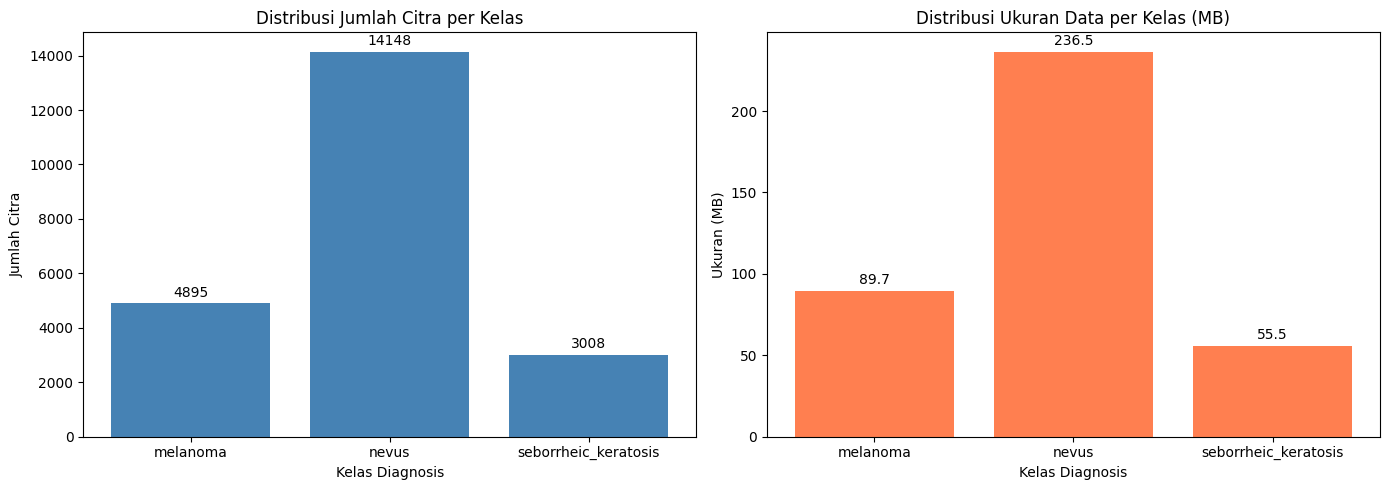

In [30]:
import matplotlib.pyplot as plt

class_names_plot = [item[0] for item in dataset_summary]
file_counts_plot = [item[1] for item in dataset_summary]
sizes_mb_plot = [item[2] for item in dataset_summary]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot jumlah file per kelas
axes[0].bar(class_names_plot, file_counts_plot, color='steelblue')
axes[0].set_title('Distribusi Jumlah Citra per Kelas')
axes[0].set_xlabel('Kelas Diagnosis')
axes[0].set_ylabel('Jumlah Citra')
for idx, val in enumerate(file_counts_plot):
    axes[0].text(idx, val + max(file_counts_plot)*0.01, str(val), ha='center', va='bottom')

# Plot ukuran data per kelas (MB)
axes[1].bar(class_names_plot, sizes_mb_plot, color='coral')
axes[1].set_title('Distribusi Ukuran Data per Kelas (MB)')
axes[1].set_xlabel('Kelas Diagnosis')
axes[1].set_ylabel('Ukuran (MB)')
for idx, val in enumerate(sizes_mb_plot):
    axes[1].text(idx, val + max(sizes_mb_plot)*0.01, f"{val:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### **24.3. Visualisasi Contoh Sampel Citra Mentah per Kelas**
Menampilkan sampel citra dermatologi asli dari masing-masing kelas diagnosis untuk memverifikasi kondisi visual data.

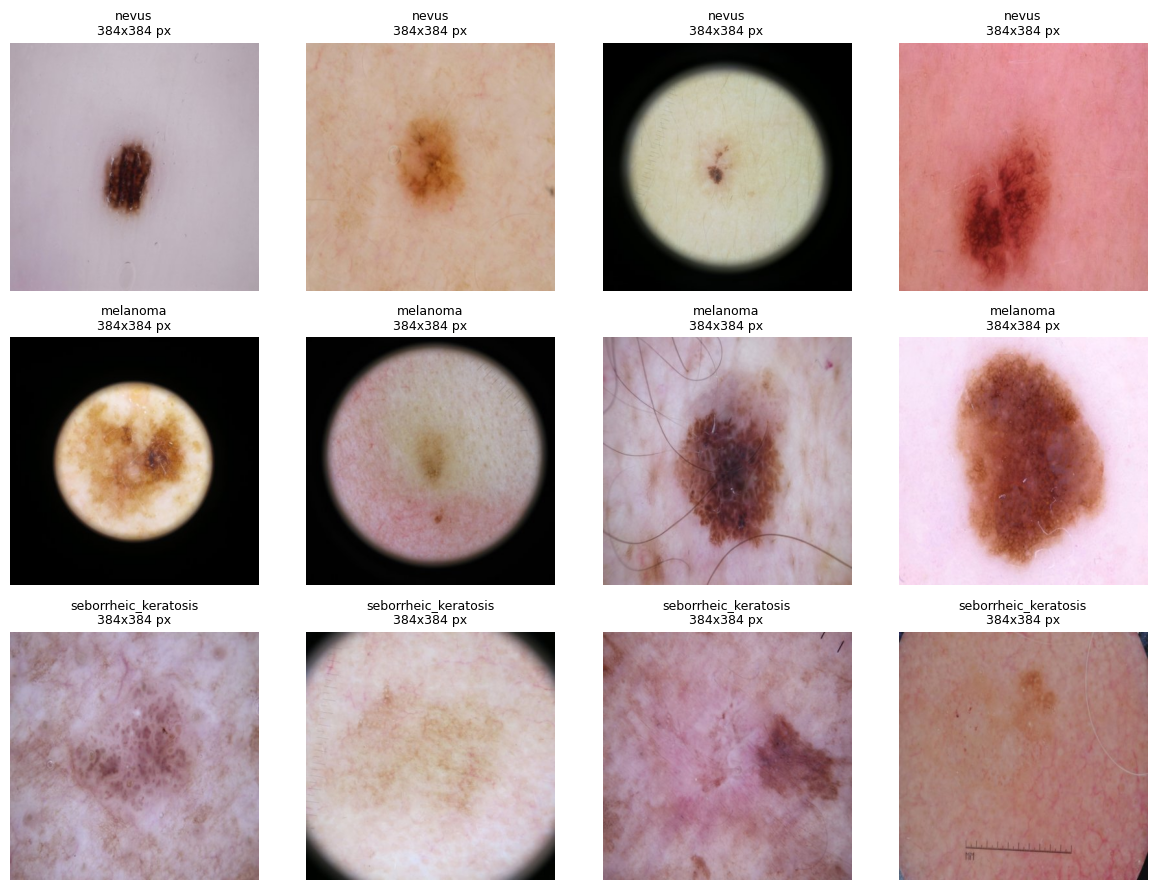

In [31]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images_per_class(base_dir, class_names, num_samples=4):
    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(num_samples * 3, len(class_names) * 3))
    if len(class_names) == 1:
        axes = axes.reshape(1, -1)

    for i, class_name in enumerate(class_names):
        class_path = base_dir / class_name
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.png"))
        if not images:
            continue
        selected_images = random.sample(images, min(len(images), num_samples))
        for j, img_path in enumerate(selected_images):
            ax = axes[i, j]
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

display_sample_images_per_class(MERGED_DATASET_DIR, CLASS_NAMES, num_samples=4)

# **FASE 5 - Pipeline Preprocessing Terdistribusi (PySpark)**
Pada tahap **Data Preparation Bagian 1**, prapemrosesan citra dilakukan secara terdistribusi menggunakan PySpark RDD:
25. Inisialisasi PySpark Session dengan konfigurasi YARN
26. Konfigurasi Resolusi Preprocessing (224x224) dan Label Mapping
27. Fungsi Modular Preprocessing Terdistribusi via PyArrow & PIL
28. Jalankan Preprocessing Terdistribusi dan Catat Throughput
29. Pencatatan Durasi Preprocessing ke File Log `results.csv`
30. Verifikasi Sampel Hasil Preprocessing RDD (`.first()`)
31. Visualisasi Perbandingan Sebelum dan Sesudah Preprocessing (Raw vs Resized vs Histogram Normalisasi)

### **25. Inisialisasi PySpark Session**
Menghubungkan kernel notebook ke PySpark on YARN menggunakan pustaka `findspark`.

In [32]:
import time
import csv

!pip install -q findspark pyarrow
import findspark

findspark.init(str(SPARK_HOME))

import os
# Fix port gateway residual Kaggle
os.environ.pop('PYSPARK_GATEWAY_PORT', None)
os.environ.pop('PYSPARK_GATEWAY_SECRET', None)
from pyspark import SparkContext
if SparkContext._active_spark_context:
    SparkContext._active_spark_context.stop()

from pyspark.sql import SparkSession
from pyspark import StorageLevel

spark = (
    SparkSession.builder
    .appName(f"skincancer-preprocessing-{SCENARIO_NAME}")
    .getOrCreate()
)

print(f"Versi Spark: {spark.version}")
print(f"Master: {spark.sparkContext.master}")
print(f"Default Parallelism: {spark.sparkContext.defaultParallelism}")

# Executor mendaftar ke driver secara asinkron; tunggu sampai jumlahnya sesuai skenario.
# Tanpa verifikasi ini, kolom num_workers pada results.csv mencatat jumlah yang DIMINTA,
# bukan yang benar-benar dialokasikan YARN, sehingga grafik speedup bisa menyesatkan.
_deadline = time.time() + 120
active_executors = 0
while time.time() < _deadline:
    # PERBAIKAN: Menggunakan getExecutorMemoryStatus dari underlying Java SparkContext
    active_executors = spark.sparkContext._jsc.sc().getExecutorMemoryStatus().size() - 1
    if active_executors >= NUM_WORKERS:
        break
    time.sleep(3)

print(f"Executor aktif: {active_executors} (target skenario: {NUM_WORKERS})")
assert active_executors == NUM_WORKERS, (
    f"YARN hanya mengalokasikan {active_executors} executor dari {NUM_WORKERS} yang diminta. "
    f"Hasil speedup tidak valid. Periksa kapasitas yarn-site.xml."
)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Versi Spark: 3.5.5
Master: yarn
Default Parallelism: 2
Executor aktif: 2 (target skenario: 2)


### **26. Konfigurasi Preprocessing dan Label Mapping**
Menetapkan target resolusi citra standar model deep learning (224x224) serta pemetaan konsisten antara nama kelas dan indeks numerik.

In [33]:
IMG_SIZE = 224

class_names = sorted(CLASS_NAMES)
label_to_index = {name: idx for idx, name in enumerate(class_names)}

print(f"Target Resolusi: {IMG_SIZE}x{IMG_SIZE} piksel (3 kanal RGB)")
print(f"Pemetaan Label ke Indeks: {label_to_index}")

Target Resolusi: 224x224 piksel (3 kanal RGB)
Pemetaan Label ke Indeks: {'melanoma': 0, 'nevus': 1, 'seborrheic_keratosis': 2}


### **27. Fungsi Modular Preprocessing Terdistribusi**
Membaca metadata path dari HDFS, membagi beban kerja ke `NUM_PARTITIONS` worker RDD, membaca byte stream via PyArrow, melakukan resize (224x224) dan normalisasi piksel [0.0, 1.0], kemudian menyimpan hasilnya di RDD cache (`persist(StorageLevel.DISK_ONLY)`).

In [34]:
def run_distributed_preprocessing(spark, hdfs_dir, num_partitions, img_size, label_to_index, monitor=None):
    # 1. Ambil daftar path citra dari HDFS lewat CLI (hanya metadata path, ringan).
    #    Dilakukan SEBELUM jendela pengukuran dibuka agar tidak mencemari elapsed_sec
    #    maupun rata-rata CPU/RAM.
    listing = subprocess.run(
        ["hdfs", "dfs", "-ls", "-R", hdfs_dir],
        capture_output=True, text=True, check=True,
    ).stdout

    image_paths = []
    for line in listing.splitlines():
        parts = line.split()
        if len(parts) < 8 or parts[0].startswith("d"):
            continue
        path = parts[-1]
        if path.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(path)

    if not image_paths:
        raise RuntimeError(f"Tidak ada citra ditemukan di direktori HDFS: {hdfs_dir}")

    expected_total = len(image_paths)
    print(f"Jumlah path citra terdaftar di HDFS: {expected_total}")

    # 2. Distribusikan path ke RDD worker
    paths_rdd = spark.sparkContext.parallelize(image_paths).repartition(num_partitions)

    java_home = os.environ["JAVA_HOME"]
    hadoop_home = str(HADOOP_HOME)
    hadoop_classpath = subprocess.run(
        [f"{hadoop_home}/bin/hadoop", "classpath", "--glob"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()

    # Akumulator agar kegagalan di executor terlihat di driver.
    # Tanpa ini, print() di dalam partisi hanya masuk stderr container dan
    # citra yang gagal hilang tanpa jejak.
    error_acc = spark.sparkContext.accumulator(0)

    # 3. Eksekusi fungsi preprocessing per partisi di worker
    def preprocess_partition(paths):
        import os
        os.environ["JAVA_HOME"] = java_home
        os.environ["HADOOP_HOME"] = hadoop_home
        os.environ["LD_LIBRARY_PATH"] = f"{hadoop_home}/lib/native:{java_home}/lib/server"
        os.environ["CLASSPATH"] = hadoop_classpath

        import io
        import numpy as np
        from PIL import Image
        from pathlib import Path as _Path
        import pyarrow.fs as pafs

        hdfs = pafs.HadoopFileSystem("localhost", port=9000)

        for path in paths:
            try:
                with hdfs.open_input_stream(path) as f:
                    raw_bytes = f.read()

                img = Image.open(io.BytesIO(raw_bytes)).convert("RGB")
                img = img.resize((img_size, img_size))
                array = np.asarray(img, dtype=np.float32) / 255.0

                label_name = path.rstrip("/").split("/")[-2]
                label = label_to_index[label_name]

                image_id = _Path(path).stem
                yield (array, label, image_id)
            except Exception as exc:
                error_acc.add(1)
                print(f"Error memproses citra {path}: {exc}")

    processed_rdd = (
        paths_rdd
        .mapPartitions(preprocess_partition)
        .persist(StorageLevel.DISK_ONLY)
    )

    # 4. Jendela pengukuran: hanya mencakup materialisasi RDD (eksekusi nyata).
    #    Monitor sumber daya dibuka dan ditutup persis pada batas yang sama
    #    dengan timer, agar elapsed_sec dan avg_cpu/avg_mem mengukur periode identik.
    if monitor is not None:
        monitor.start()
    start_time = time.time()
    image_count = processed_rdd.count()
    elapsed_sec = time.time() - start_time
    if monitor is not None:
        monitor.stop()

    partition_sizes = processed_rdd.mapPartitions(lambda it: [sum(1 for _ in it)]).collect()
    failed = error_acc.value

    print("Prapemrosesan terdistribusi selesai!")
    print(f"Jumlah partisi aktual: {len(partition_sizes)} (target: {num_partitions})")
    print(f"Distribusi citra per partisi: {partition_sizes}")
    if failed:
        print(f"PERINGATAN: {failed} citra gagal diproses di executor "
              f"({image_count}/{expected_total} berhasil).")
    else:
        print(f"Seluruh {image_count} citra berhasil diproses tanpa kegagalan.")

    return processed_rdd, elapsed_sec, image_count

### **28. Jalankan Preprocessing Terdistribusi dan Catat Throughput**
Mengeksekusi pipeline preprocessing pada HDFS dan mengukur durasi serta kecepatan proses (citra/detik).

In [35]:
import psutil
import threading
import time

class ResourceMonitor:
    """Sampling CPU dan RAM sistem. start()/stop() dipanggil dari dalam
    run_distributed_preprocessing agar jendela sampling persis sama dengan
    jendela timer preprocessing."""

    def __init__(self, interval_sec=0.5):
        self.interval_sec = interval_sec
        self.keep_running = False
        self.cpu_records = []
        self.mem_records = []
        self._thread = None

    def _loop(self):
        while self.keep_running:
            self.cpu_records.append(psutil.cpu_percent(interval=None))
            self.mem_records.append(psutil.virtual_memory().used / (1024 * 1024))
            time.sleep(self.interval_sec)

    def start(self):
        self.cpu_records.clear()
        self.mem_records.clear()
        psutil.cpu_percent(interval=None)  # warmup: panggilan pertama selalu 0.0
        self.keep_running = True
        self._thread = threading.Thread(target=self._loop)
        self._thread.start()

    def stop(self):
        self.keep_running = False
        if self._thread is not None:
            self._thread.join()
            self._thread = None

monitor = ResourceMonitor()

processed_rdd, preprocessing_time_sec, image_count = run_distributed_preprocessing(
    spark, HDFS_WORKDIR, NUM_PARTITIONS, IMG_SIZE, label_to_index, monitor=monitor
)

avg_cpu = sum(monitor.cpu_records) / len(monitor.cpu_records) if monitor.cpu_records else 0
avg_mem = sum(monitor.mem_records) / len(monitor.mem_records) if monitor.mem_records else 0

throughput = image_count / preprocessing_time_sec if preprocessing_time_sec > 0 else 0
print(f"Total citra diproses : {image_count} citra")
print(f"Durasi prapemrosesan : {preprocessing_time_sec:.2f} detik")
print(f"Throughput komputasi : {throughput:.1f} citra/detik")
print(f"Rata-rata CPU Usage  : {avg_cpu:.2f}% (seluruh sistem, {len(monitor.cpu_records)} sampel)")
print(f"Rata-rata RAM Usage  : {avg_mem:.2f} MB (seluruh sistem, bukan khusus executor)")

Jumlah path citra terdaftar di HDFS: 22051


Prapemrosesan terdistribusi selesai!
Jumlah partisi aktual: 2 (target: 2)
Distribusi citra per partisi: [11020, 11031]
Seluruh 22051 citra berhasil diproses tanpa kegagalan.
Total citra diproses : 22051 citra
Durasi prapemrosesan : 122.06 detik
Throughput komputasi : 180.7 citra/detik
Rata-rata CPU Usage  : 66.28% (seluruh sistem, 244 sampel)
Rata-rata RAM Usage  : 6936.92 MB (seluruh sistem, bukan khusus executor)


### **29. Pencatatan Durasi Preprocessing ke File Log `results.csv`**
Merekam metrik waktu prapemrosesan ke file `results.csv` sebagai dokumentasi kinerja komputasi.

In [36]:
RESULTS_LOG_PATH = PROJECT_DIR / "results.csv"
LOG_COLUMNS = [
    "timestamp", "scenario", "num_workers", "num_partitions", "stage",
    "elapsed_sec", "image_count", "avg_cpu_percent", "avg_mem_mb",
    "accuracy", "f1_score", "loss", "roc_auc"
]

def ensure_log_header():
    """Validasi skema results.csv sebelum menulis.

    RESULTS_LOG_PATH berada di storage persisten (Google Drive), sehingga file
    dari versi notebook lama dengan jumlah kolom berbeda bisa saja masih ada.
    Mengecek keberadaan file saja tidak cukup: header lama tidak akan ditulis
    ulang dan baris 13 kolom akan menempel di bawah header yang salah.
    """
    if RESULTS_LOG_PATH.exists():
        with open(RESULTS_LOG_PATH, newline="") as f:
            header = next(csv.reader(f), [])
        if header != LOG_COLUMNS:
            backup = RESULTS_LOG_PATH.with_name(
                f"results_legacy_{time.strftime('%Y%m%d_%H%M%S')}.csv"
            )
            RESULTS_LOG_PATH.rename(backup)
            print(f"Skema lama terdeteksi ({len(header)} kolom). File diarsipkan ke: {backup.name}")

    if not RESULTS_LOG_PATH.exists():
        with open(RESULTS_LOG_PATH, "w", newline="") as f:
            csv.writer(f).writerow(LOG_COLUMNS)
        print(f"File log baru dibuat dengan {len(LOG_COLUMNS)} kolom.")

def log_preprocessing_time(scenario_name, num_workers, num_partitions, elapsed_sec, image_count, avg_cpu, avg_mem):
    ensure_log_header()
    with open(RESULTS_LOG_PATH, "a", newline="") as f:
        csv.writer(f).writerow([
            time.strftime("%Y-%m-%d %H:%M:%S"),
            scenario_name, num_workers, num_partitions,
            "preprocessing", f"{elapsed_sec:.2f}", image_count,
            f"{avg_cpu:.2f}", f"{avg_mem:.2f}",
            "", "", "", ""
        ])

log_preprocessing_time(SCENARIO_NAME, NUM_WORKERS, NUM_PARTITIONS, preprocessing_time_sec, image_count, avg_cpu, avg_mem)
print(f"Log preprocessing tersimpan di {RESULTS_LOG_PATH}")

File log baru dibuat dengan 13 kolom.
Log preprocessing tersimpan di /kaggle/working/riset_kanker_kulit/results.csv


### **30. Verifikasi Sampel Hasil Preprocessing RDD**
Mengambil sampel pertama dari RDD terdistribusi untuk memvalidasi dimensi array (224, 224, 3) dan tipe data nilai piksel.

In [ ]:
sample_array, sample_label, sample_id = processed_rdd.first()
print(f"Bentuk dimensi array (Shape): {sample_array.shape}")
print(f"Tipe data: {sample_array.dtype}")
print(f"Nilai piksel minimum: {sample_array.min():.4f}, maksimum: {sample_array.max():.4f}")
print(f"ID Citra: {sample_id}, Label numerik: {sample_label} ({class_names[sample_label]})")

assert sample_array.shape == (IMG_SIZE, IMG_SIZE, 3), "Dimensi citra tidak sesuai spesifikasi 224x224x3!"
assert 0.0 <= sample_array.min() and sample_array.max() <= 1.0, "Normalisasi piksel di luar rentang [0, 1]!"
print("Sanity check prapemrosesan berhasil 100%.")

Bentuk dimensi array (Shape): (224, 224, 3)
Tipe data: float32
Nilai piksel minimum: 0.0000, maksimum: 0.8824
ID Citra: ISIC_0000030_downsampled, Label numerik: 0 (melanoma)
Sanity check prapemrosesan berhasil 100%.


### **31. Visualisasi Perbandingan Sebelum dan Sesudah Preprocessing**
Menampilkan perbandingan komparatif 3 kolom per sampel:
1. Citra Asli (ukuran piksel asli)
2. Citra Hasil Preprocessing (seragam 224x224)
3. Histogram Distribusi Piksel Ternormalisasi [0.0, 1.0]

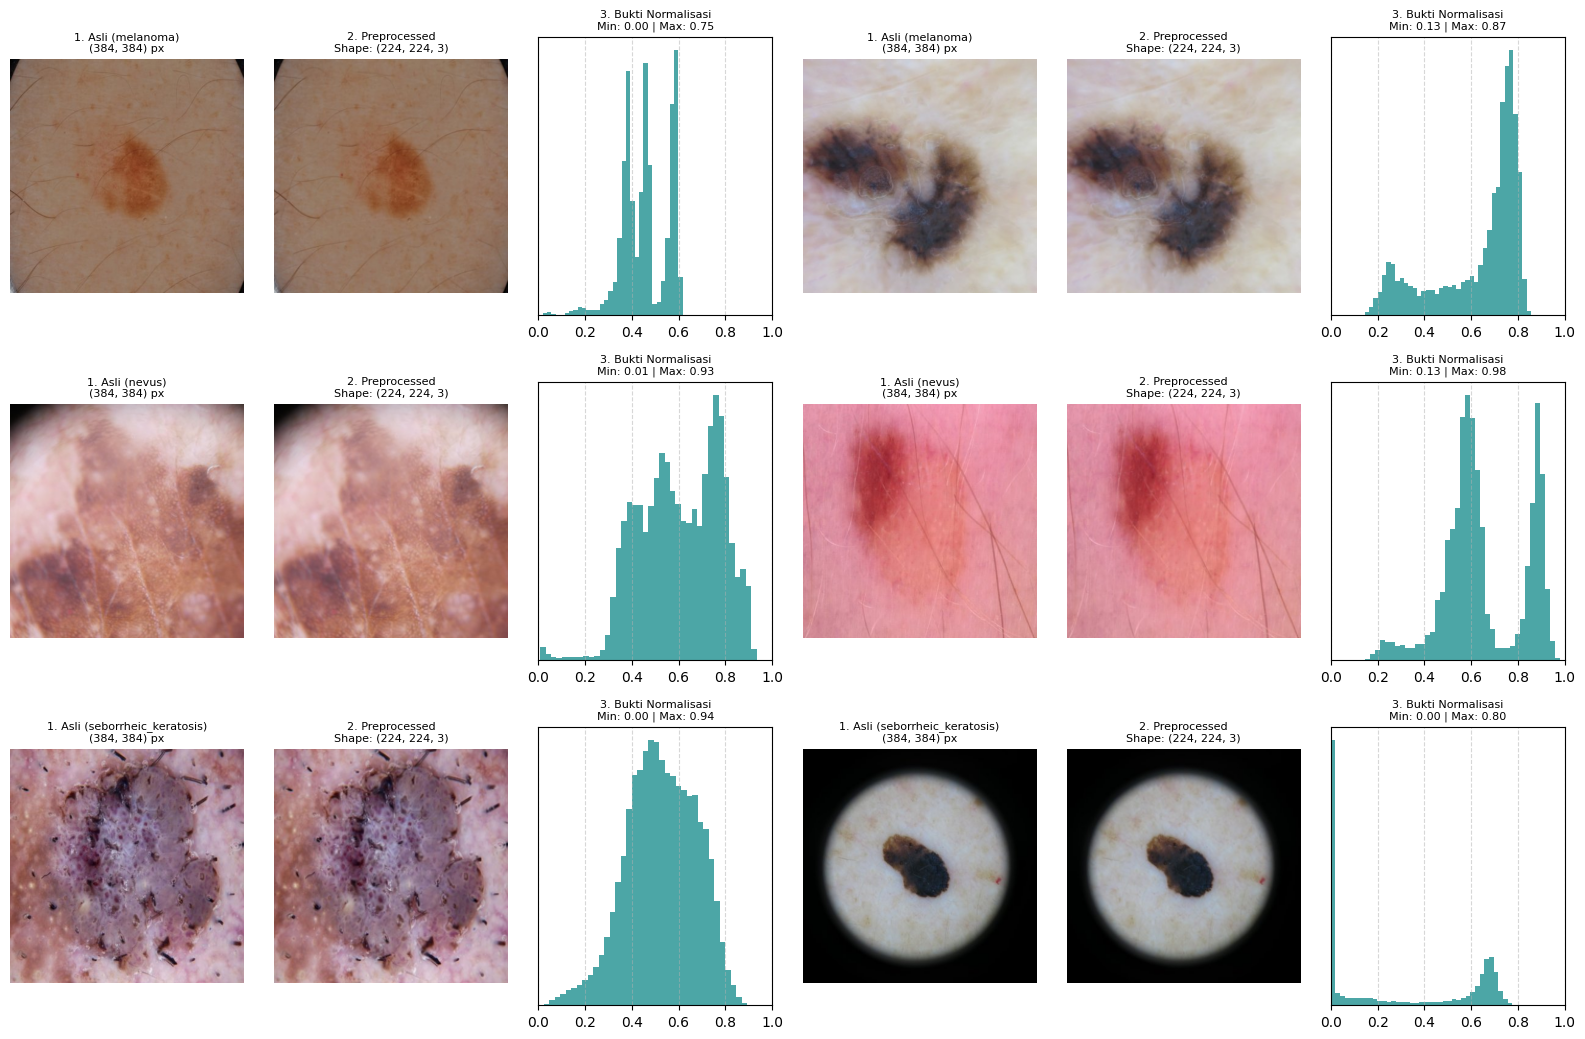

Grafik bukti normalisasi tersimpan di: /kaggle/working/riset_kanker_kulit/preprocessing_norm_proof_irisan_2W2P.png


In [38]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import io
import random

# Kumpulkan path citra per kelas dari HDFS untuk perbandingan
listing = subprocess.run(
    ["hdfs", "dfs", "-ls", "-R", HDFS_WORKDIR],
    capture_output=True, text=True, check=True
).stdout

paths_by_class = {c: [] for c in class_names}
for line in listing.splitlines():
    parts = line.split()
    if len(parts) > 0:
        path = parts[-1]
        if path.lower().endswith(('.jpg', '.jpeg', '.png')):
            label_name = path.rstrip("/").split("/")[-2]
            if label_name in paths_by_class:
                paths_by_class[label_name].append(path)

samples_per_class = 2
fig, axes = plt.subplots(len(class_names), samples_per_class * 3, figsize=(16, 3.5 * len(class_names)))
if len(class_names) == 1:
    axes = axes.reshape(1, -1)

for i, class_name in enumerate(class_names):
    sample_paths = random.sample(paths_by_class[class_name], min(len(paths_by_class[class_name]), samples_per_class))
    for j, sample_path in enumerate(sample_paths):
        cat_result = subprocess.run(
            ["hdfs", "dfs", "-cat", sample_path],
            capture_output=True, check=True
        )
        raw_bytes = cat_result.stdout
        original_img = Image.open(io.BytesIO(raw_bytes)).convert("RGB")
        resized_img = original_img.resize((IMG_SIZE, IMG_SIZE))
        preprocessed_array = np.asarray(resized_img, dtype=np.float32) / 255.0

        col_base = j * 3
        # 1. Asli
        ax_orig = axes[i, col_base]
        ax_orig.imshow(original_img)
        ax_orig.set_title(f"1. Asli ({class_name})\n{original_img.size} px", fontsize=8)
        ax_orig.axis("off")

        # 2. Preprocessed
        ax_prep = axes[i, col_base + 1]
        ax_prep.imshow(preprocessed_array)
        ax_prep.set_title(f"2. Preprocessed\nShape: {preprocessed_array.shape}", fontsize=8)
        ax_prep.axis("off")

        # 3. Histogram
        ax_hist = axes[i, col_base + 2]
        ax_hist.hist(preprocessed_array.ravel(), bins=40, color='teal', alpha=0.7)
        ax_hist.set_title(f"3. Bukti Normalisasi\nMin: {preprocessed_array.min():.2f} | Max: {preprocessed_array.max():.2f}", fontsize=8)
        ax_hist.set_xlim(0, 1)
        ax_hist.set_yticks([])
        ax_hist.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
vis_path = PROJECT_DIR / f"preprocessing_norm_proof_{SCENARIO_NAME}.png"
plt.savefig(vis_path)
plt.show()
print(f"Grafik bukti normalisasi tersimpan di: {vis_path}")

# **FASE 6 - Data Splitting & Pemodelan**
Pada tahap **Data Preparation Bagian 2 & Modeling Bagian 1**:
32. Pembagian Data Train, Validation, dan Test (Stratifikasi Bebas Kebocoran)
33. Pengumpulan Data ke Driver dalam Format NumPy Array
34. Konstruksi Arsitektur Model Deep Learning (ResNet-50 + Triplet Attention - Model AK85)
35. Verifikasi Sanity Check Model (Forward Pass Dummy Batch & Model Summary)

### **32. Pembagian Data Train, Validation, dan Test Menggunakan CSV Split**
Pembagian data memanfaatkan partisi split yang telah kita susun secara metodologis pada tahap Data Understanding & Preparation sebelumnya:
- Pada **Skenario Irisan 3 Kelas**, pembagian membaca langsung file split `dataset_irisan_3kelas_train.csv`, `val.csv`, dan `test.csv` yang dibuat dengan `StratifiedGroupKFold` pada `lesion_id` sehingga **100% bebas kebocoran lesi pasien (*zero lesion leakage*)**.
- Pada **Skenario Biner**, pembagian dilakukan secara deterministik terstratifikasi per `image_id` dari CSV master.
Data uji (`test_rdd`) diisolasi penuh dan tidak akan pernah tersentuh pada tahap pelatihan.

In [39]:
split_dir = csv_path.parent
train_csv_path = split_dir / "dataset_irisan_3kelas_train.csv"
val_csv_path = split_dir / "dataset_irisan_3kelas_val.csv"
test_csv_path = split_dir / "dataset_irisan_3kelas_test.csv"

# Fallback pencarian di subfolder jika letak CSV di subfolder Dataset
if not train_csv_path.exists():
    for search_p in [PROJECT_DIR / "Dataset" / "csv_irisan_3kelas", Path("Dataset/csv_irisan_3kelas"), Path("/kaggle/input")]:
        cand_train = search_p / "dataset_irisan_3kelas_train.csv"
        if cand_train.exists():
            split_dir = search_p
            train_csv_path = split_dir / "dataset_irisan_3kelas_train.csv"
            val_csv_path = split_dir / "dataset_irisan_3kelas_val.csv"
            test_csv_path = split_dir / "dataset_irisan_3kelas_test.csv"
            break

if train_csv_path.exists() and val_csv_path.exists() and test_csv_path.exists():
    print("Memuat partisi split anti-kebocoran dari file CSV resmi:")
    df_train_csv = pd.read_csv(train_csv_path)
    df_val_csv = pd.read_csv(val_csv_path)
    df_test_csv = pd.read_csv(test_csv_path)

    train_ids = set(df_train_csv["image_id"].astype(str))
    val_ids = set(df_val_csv["image_id"].astype(str))
    test_ids = set(df_test_csv["image_id"].astype(str))

    print(f"  - Train Set : {len(train_ids)} citra")
    print(f"  - Val Set   : {len(val_ids)} citra")
    print(f"  - Test Set  : {len(test_ids)} citra (100% Bebas Kebocoran)")
    
    print("\nDistribusi label medis pada CSV split:")
    print(f"  - Train Set : {df_train_csv['harmonized_label'].value_counts().to_dict()}")
    print(f"  - Val Set   : {df_val_csv['harmonized_label'].value_counts().to_dict()}")
    print(f"  - Test Set  : {df_test_csv['harmonized_label'].value_counts().to_dict()}")
else:
    raise FileNotFoundError("File split terpisah tidak ditemukan! Pastikan file CSV split telah diunggah.")


Memuat partisi split anti-kebocoran dari file CSV resmi:
  - Train Set : 17656 citra
  - Val Set   : 2192 citra
  - Test Set  : 2203 citra (100% Bebas Kebocoran)

Distribusi label medis pada CSV split:
  - Train Set : {'NV': 11302, 'MEL': 3902, 'BKL': 2452}
  - Val Set   : {'NV': 1455, 'MEL': 450, 'BKL': 287}
  - Test Set  : {'NV': 1391, 'MEL': 543, 'BKL': 269}


### **33. Pengumpulan Data ke Driver dalam Format NumPy Array**
Pada arsitektur Tipe 1, partisi data yang telah diproses dikumpulkan ke memori driver sebagai array NumPy. Subset uji (`X_test`, `y_test`) diisolasi secara ketat dan **TIDAK BOLEH** disentuh selama proses pelatihan!

In [40]:
import gc
import io
import os
import shutil
import subprocess
import time

import numpy as np
from tensorflow.keras.utils import to_categorical

# =============================================================================
# TAHAP A - Executor menulis SHARD kecil ke HDFS.
# Tidak ada lagi partisi utuh (~6 GiB) yang ditarik ke satu executor / ke driver.
# Memori per task dibatasi oleh SHARD_SIZE, bukan oleh NUM_PARTITIONS.
# =============================================================================
SHARD_SIZE = 64                              # 64 citra x 588 KiB = ~37 MiB per shard
SHARD_HDFS_DIR = f"{HDFS_WORKDIR}_shards"    # sengaja DI LUAR HDFS_WORKDIR (jangan tercampur dengan citra)

_java_home = os.environ["JAVA_HOME"]
_hadoop_home = str(HADOOP_HOME)
_hadoop_classpath = subprocess.run(
    [f"{_hadoop_home}/bin/hadoop", "classpath", "--glob"],
    capture_output=True, text=True, check=True,
).stdout.strip()
_shard_dir, _shard_size = SHARD_HDFS_DIR, SHARD_SIZE


def write_shards(part_idx, rows):
    import io
    import os
    import numpy as np

    os.environ["JAVA_HOME"] = _java_home
    os.environ["HADOOP_HOME"] = _hadoop_home
    os.environ["LD_LIBRARY_PATH"] = f"{_hadoop_home}/lib/native:{_java_home}/lib/server"
    os.environ["CLASSPATH"] = _hadoop_classpath
    import pyarrow.fs as pafs

    hdfs = pafs.HadoopFileSystem("localhost", port=9000)

    xs, ys, ids = [], [], []
    n_shards = 0
    n_rows = 0

    def flush():
        nonlocal xs, ys, ids, n_shards, n_rows
        if not xs:
            return
        buf = io.BytesIO()
        np.savez(buf, x=np.stack(xs), y=np.asarray(ys, dtype=np.int32), ids=np.asarray(ids))
        # Nama deterministik: jika task di-retry, file lama ditimpa (idempotent).
        with hdfs.open_output_stream(f"{_shard_dir}/p{part_idx:03d}_s{n_shards:05d}.npz") as out:
            out.write(buf.getbuffer())
        n_rows += len(xs)
        n_shards += 1
        xs, ys, ids = [], [], []

    for arr, lbl, iid in rows:
        xs.append(arr)
        ys.append(lbl)
        ids.append(iid)
        if len(xs) >= _shard_size:
            flush()
    flush()
    yield (part_idx, n_shards, n_rows)


subprocess.run(["hdfs", "dfs", "-rm", "-r", "-f", "-skipTrash", SHARD_HDFS_DIR], capture_output=True)
subprocess.run(["hdfs", "dfs", "-mkdir", "-p", SHARD_HDFS_DIR], check=True)

print(f"Executor menulis shard ({SHARD_SIZE} citra/shard) ke HDFS: {SHARD_HDFS_DIR}")
_t0 = time.time()
shard_report = sorted(processed_rdd.mapPartitionsWithIndex(write_shards).collect())
_rows_written = sum(r[2] for r in shard_report)
print(f"Selesai dalam {time.time() - _t0:.1f} detik | "
      f"{sum(r[1] for r in shard_report)} shard | {_rows_written} citra")
for _p, _ns, _nr in shard_report:
    print(f"  - partisi {_p}: {_nr} citra -> {_ns} shard")

if "image_count" in globals():
    assert _rows_written == image_count, (
        f"Jumlah citra di shard ({_rows_written}) != hasil preprocessing ({image_count})."
    )

# Cache DISK_ONLY tidak diperlukan lagi -> bebaskan disk sebelum shard diunduh ke lokal.
try:
    processed_rdd.unpersist(blocking=True)
    print("Cache processed_rdd berhasil dibersihkan.")
except Exception as e:
    print(f"Pembersihan cache: {e}")

# =============================================================================
# TAHAP B - Driver membaca shard satu per satu ke array NumPy (memori driver
# hanya menampung array akhir + 1 shard, tanpa duplikasi ~6 GiB per partisi).
# =============================================================================
print("\nMengumpulkan data Train, Val, dan Test dari shard ke memori driver...")

n_train, n_val, n_test = len(train_ids), len(val_ids), len(test_ids)

X_train = np.empty((n_train, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
y_train = np.empty((n_train,), dtype=np.int32)
X_val = np.empty((n_val, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
y_val = np.empty((n_val,), dtype=np.int32)
X_test = np.empty((n_test, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
y_test = np.empty((n_test,), dtype=np.int32)

LOCAL_SHARD_DIR = DATA_DIR.parent / "shards_local"
if LOCAL_SHARD_DIR.exists():
    shutil.rmtree(LOCAL_SHARD_DIR)
subprocess.run(["hdfs", "dfs", "-get", SHARD_HDFS_DIR, str(LOCAL_SHARD_DIR)], check=True)

idx_train = idx_val = idx_test = 0
for shard_path in sorted(LOCAL_SHARD_DIR.glob("*.npz")):
    with np.load(shard_path) as z:
        xs, ys, ids = z["x"], z["y"], z["ids"]
    for k in range(len(ids)):
        img_stem = str(ids[k])
        if img_stem in train_ids:
            if idx_train < n_train:
                X_train[idx_train] = xs[k]
                y_train[idx_train] = ys[k]
                idx_train += 1
        elif img_stem in val_ids:
            if idx_val < n_val:
                X_val[idx_val] = xs[k]
                y_val[idx_val] = ys[k]
                idx_val += 1
        elif img_stem in test_ids:
            if idx_test < n_test:
                X_test[idx_test] = xs[k]
                y_test[idx_test] = ys[k]
                idx_test += 1
    del xs, ys, ids
    shard_path.unlink()          # hemat disk: shard yang sudah dimuat langsung dihapus

print("Pengumpulan data selesai:")
print(f"  - Terkumpul Train: {idx_train}/{n_train}")
print(f"  - Terkumpul Val  : {idx_val}/{n_val}")
print(f"  - Terkumpul Test : {idx_test}/{n_test}")

# Trim jika ada selisih
X_train, y_train = X_train[:idx_train], y_train[:idx_train]
X_val, y_val = X_val[:idx_val], y_val[:idx_val]
X_test, y_test = X_test[:idx_test], y_test[:idx_test]

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"\nDimensi Train Set: X={X_train.shape}, y={y_train_cat.shape}")
print(f"Dimensi Val Set  : X={X_val.shape}, y={y_val_cat.shape}")
print(f"Dimensi Test Set : X={X_test.shape}, y={y_test_cat.shape}")

# Bersihkan shard sementara (lokal + HDFS)
shutil.rmtree(LOCAL_SHARD_DIR, ignore_errors=True)
subprocess.run(["hdfs", "dfs", "-rm", "-r", "-f", "-skipTrash", SHARD_HDFS_DIR], capture_output=True)

gc.collect()

_total_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes) / (1024 ** 2)
print(f"Total memori array di driver: {_total_mb:.1f} MB (~{_total_mb / 1024:.2f} GB)")

# OPSIONAL: Spark/YARN tidak dipakai lagi setelah titik ini. Menghentikannya
# melepas RAM (executor + JVM driver) sebelum pelatihan GPU di Fase 7.
spark.stop()
print("SparkSession dihentikan; RAM executor dilepas.")

Executor menulis shard (64 citra/shard) ke HDFS: /user/skincancer/irisan_shards


Selesai dalam 121.2 detik | 346 shard | 22051 citra
  - partisi 0: 11020 citra -> 173 shard
  - partisi 1: 11031 citra -> 173 shard
Cache processed_rdd berhasil dibersihkan.

Mengumpulkan data Train, Val, dan Test dari shard ke memori driver...
Pengumpulan data selesai:
  - Terkumpul Train: 17656/17656
  - Terkumpul Val  : 2192/2192
  - Terkumpul Test : 2203/2203

Dimensi Train Set: X=(17656, 224, 224, 3), y=(17656, 3)
Dimensi Val Set  : X=(2192, 224, 224, 3), y=(2192, 3)
Dimensi Test Set : X=(2203, 224, 224, 3), y=(2203, 3)
Total memori array di driver: 12662.1 MB (~12.37 GB)
SparkSession dihentikan; RAM executor dilepas.


### **34. Arsitektur Model Deep Learning: ResNet-50 + Triplet Attention**
Membangun arsitektur model baseline AK85:
- **Backbone:** ResNet-50 pre-trained ImageNet (input 224x224x3).
- **Triplet Attention Module (WACV 2021):** Ditempatkan pada resolusi 14x14 (`conv4_block6_out`) dengan 3 branch interaktif: Channel-Height (C-H), Channel-Width (C-W), dan Spatial Attention (H-W).
- **Multi-Pooling Head:** Menggabungkan fitur Global Average Pooling, Global Max Pooling, dan Attended Features.
- **Classifier:** Batch Normalization, Dropout (0.5 & 0.4), Dense(512), Dense(256), dan Softmax Output.

In [41]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, GlobalMaxPooling2D,
    BatchNormalization, Dropout, Concatenate, Input,
    Conv2D, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# ---- PENYELARASAN SKALA INPUT ----
class ResNetCaffePreprocess(tf.keras.layers.Layer):
    """Ubah citra RGB [0, 1] menjadi format 'caffe' (BGR, mean-subtracted).

    Bobot ResNet50 ImageNet dilatih dengan skema preprocessing caffe, bukan
    rentang [0, 1]. Karena base model dibekukan (trainable=False), seluruh
    fitur dihitung pada distribusi input yang salah bila skala tidak
    diselaraskan. Layer ini setara dengan
    tf.keras.applications.resnet50.preprocess_input, tetapi ditulis eksplisit
    agar tetap serializable dan tidak bergantung pada perilaku backend.
    """
    def call(self, x):
        x = x * 255.0
        x = x[..., ::-1]  # RGB -> BGR
        mean = tf.constant([103.939, 116.779, 123.68], dtype=x.dtype)
        return x - mean

# ---- MODUL TRIPLET ATTENTION ----
class ZPool(tf.keras.layers.Layer):
    def call(self, x):
        max_out = tf.reduce_max(x, axis=-1, keepdims=True)
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        return tf.concat([max_out, avg_out], axis=-1)

class AttentionGate(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.zpool = ZPool()
        self.conv = Conv2D(1, kernel_size=3, padding='same', use_bias=False)
        self.sigmoid = Activation('sigmoid')

    def call(self, x):
        out = self.zpool(x)
        out = self.conv(out)
        out = self.sigmoid(out)
        return out

class TripletAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.gate_ch = AttentionGate()
        self.gate_cw = AttentionGate()
        self.gate_hw = AttentionGate()

    def call(self, x):
        # Branch 1: C x H
        x_perm1 = tf.transpose(x, perm=[0, 3, 2, 1])
        attn1 = self.gate_ch(x_perm1)
        x_perm1 = x_perm1 * attn1
        x_perm1 = tf.transpose(x_perm1, perm=[0, 3, 2, 1])

        # Branch 2: C x W
        x_perm2 = tf.transpose(x, perm=[0, 1, 3, 2])
        attn2 = self.gate_cw(x_perm2)
        x_perm2 = x_perm2 * attn2
        x_perm2 = tf.transpose(x_perm2, perm=[0, 1, 3, 2])

        # Branch 3: H x W
        attn3 = self.gate_hw(x)
        x_branch3 = x * attn3

        return (x_perm1 + x_perm2 + x_branch3) / 3.0

# ---- PEMBANGUNAN MODEL LENGKAP ----
def build_ak85_model(img_size=IMG_SIZE, num_classes=3):
    # RDD Spark menghasilkan citra ternormalisasi [0, 1]; konversi ke skala
    # ImageNet dilakukan di dalam graf model sehingga pipeline prapemrosesan
    # terdistribusi tidak perlu diubah.
    inputs = Input(shape=(img_size, img_size, 3), name='input_rgb_01')
    x_pre = ResNetCaffePreprocess(name='resnet_caffe_preprocess')(inputs)

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=x_pre
    )
    base_model.trainable = False

    # Triplet Attention pada conv4 (14x14x1024)
    conv4_out = base_model.get_layer('conv4_block6_out').output
    attended = TripletAttention(name='triplet_attention')(conv4_out)
    attended_avg = GlobalAveragePooling2D(name='att_avg_pool')(attended)

    # Fitur utama ResNet50 (7x7x2048)
    x_main = base_model.output
    avg_pool = GlobalAveragePooling2D()(x_main)
    max_pool = GlobalMaxPooling2D()(x_main)

    # Penggabungan multi-scale pooling: (2048 + 2048 + 1024 = 5120 dimensi)
    x = Concatenate()([avg_pool, max_pool, attended_avg])
    x = BatchNormalization()(x)

    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.4)(x)

    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=predictions)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Diperlukan saat memuat kembali model tersimpan: load_model(path, custom_objects=CUSTOM_OBJECTS)
CUSTOM_OBJECTS = {
    "ResNetCaffePreprocess": ResNetCaffePreprocess,
    "ZPool": ZPool,
    "AttentionGate": AttentionGate,
    "TripletAttention": TripletAttention,
}

print("Fungsi pembangun model build_ak85_model() berhasil didefinisikan.")

Fungsi pembangun model build_ak85_model() berhasil didefinisikan.


### **35. Verifikasi Sanity Check Model**
Menguji forward pass model menggunakan batch dummy (4 citra ukuran 224x224) untuk memastikan dimensi output sesuai dengan jumlah kelas target.

In [42]:
_test_model = build_ak85_model()
_dummy_batch = np.zeros((4, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
_dummy_output = _test_model.predict(_dummy_batch, verbose=0)

print(f"Output shape dummy batch size 4: {_dummy_output.shape}")
assert _dummy_output.shape == (4, 3), f"Shape tidak sesuai! Diharapkan (4, 3), didapat {_dummy_output.shape}"

# Verifikasi penyelarasan skala: input [0,1] harus keluar dalam rentang caffe
_probe = tf.keras.Model(
    _test_model.input,
    _test_model.get_layer('resnet_caffe_preprocess').output
)
_scaled = _probe.predict(np.ones((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), verbose=0)
print(f"Cek skala input: piksel 1.0 -> {_scaled.min():.2f} s/d {_scaled.max():.2f} (harap ~131 s/d ~151)")
assert _scaled.max() > 100, "Layer preprocessing ResNet tidak aktif!"

print(f"Total parameter model: {_test_model.count_params():,}")
print("Sanity check forward pass model berhasil 100%.")

del _test_model, _dummy_batch, _dummy_output, _probe, _scaled
tf.keras.backend.clear_session()

I0000 00:00:1789971653.533818      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789971653.538175      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


I0000 00:00:1789971666.227766   96281 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Output shape dummy batch size 4: (4, 3)
Cek skala input: piksel 1.0 -> 131.32 s/d 151.06 (harap ~131 s/d ~151)
Total parameter model: 26,362,297
Sanity check forward pass model berhasil 100%.


# **FASE 7 - Pelatihan Terpusat GPU & Evaluasi Komprehensif**
Sesuai metodologi CRISP-DM pada tahap **Modeling Bagian 2 & Evaluation**:
36. Konfigurasi Pelatihan & Penanganan Ketimpangan Kelas (Class Weights)
37. Setup Callbacks Pelatihan (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
38. Eksekusi Pelatihan Terpusat pada GPU Driver (`model.fit`)
39. Visualisasi Kurva Pembelajaran (Loss & Akurasi: Train vs Validation)
40. Evaluasi Menyeluruh pada Test Set (Normalized Confusion Matrix & Classification Report)
41. Pencatatan Hasil Akhir ke File Log `results.csv`
42. Kesimpulan Data Scientist & Kesiapan Model

### **36. Konfigurasi Pelatihan & Penanganan Ketimpangan Kelas**
Menghitung bobot kelas (class weights) untuk mengatasi ketimpangan sebaran data citra secara otomatis.

In [43]:
from sklearn.utils.class_weight import compute_class_weight

BATCH_SIZE = 32
print(f"Skenario: {SCENARIO_NAME} | Batch Size: {BATCH_SIZE} | Epochs: {EPOCHS}")

# Hitung class weights
_present_classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=_present_classes,
    y=y_train
)

# zip(_present_classes, ...) bukan enumerate(): bila ada kelas yang absen dari
# train set, enumerate akan menggeser pemetaan indeks dan memberi bobot ke
# kelas yang keliru.
class_weights = {int(c): float(w) for c, w in zip(_present_classes, class_weights_arr)}

if len(_present_classes) < NUM_CLASSES:
    print(f"PERINGATAN: hanya {len(_present_classes)} dari {NUM_CLASSES} kelas hadir di train set.")

print(f"Class Weights seimbang: {class_weights}")

Skenario: irisan_2W2P | Batch Size: 32 | Epochs: 15
Class Weights seimbang: {0: 1.5082863488809157, 1: 0.5207337934288916, 2: 2.4002175095160414}


### **37. Setup Callbacks Pelatihan**
Menyiapkan callback untuk adaptasi learning rate, early stopping jika konvergen, dan penyimpanan bobot model terbaik.

In [44]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Keras 3 mewajibkan akhiran .keras untuk checkpoint model utuh
# (.weights.h5 hanya bila save_weights_only=True). Ekstensi .h5 menyebabkan
# ValueError saat callback dibuat, sebelum model.fit sempat berjalan.
MODEL_SAVE_PATH = PROJECT_DIR / f"best_model_{SCENARIO_NAME}.keras"

# Seluruh callback memantau val_loss. Sebelumnya ModelCheckpoint memakai
# val_accuracy sementara EarlyStopping mengembalikan bobot terbaik menurut
# val_loss, sehingga model yang dievaluasi berbeda dari model yang tersimpan.
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(MODEL_SAVE_PATH),
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )
]

print(f"Callbacks siap dipasangkan ke pelatihan. Checkpoint: {MODEL_SAVE_PATH.name}")

Callbacks siap dipasangkan ke pelatihan. Checkpoint: best_model_irisan_2W2P.keras


### **38. Eksekusi Pelatihan Terpusat pada GPU Driver**
Melatih model ResNet-50 + Triplet Attention pada driver GPU menggunakan subset Train dan Validation saja. Data uji **TIDAK TERLIBAT** pada langkah ini.

In [45]:
import time
import numpy as np
import tensorflow as tf

# Keras 3 membungkus array NumPy penuh ke tf.data (from_tensors) pada model.fit(X, y),
# sehingga memori host melonjak ~1,9x ukuran data (hasil ukur). Generator batch ini hanya
# mengiris array per batch, jadi tidak ada salinan penuh X_train di RAM.
_PyDatasetBase = getattr(tf.keras.utils, "PyDataset", None) or tf.keras.utils.Sequence


class BatchSequence(_PyDatasetBase):
    def __init__(self, X, y, batch_size, shuffle=True, seed=42, **kwargs):
        super().__init__(**kwargs)
        self.X, self.y = X, y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(X))
        if shuffle:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        sel = np.sort(self.indices[idx * self.batch_size:(idx + 1) * self.batch_size])
        return self.X[sel], self.y[sel]

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)


# Verifikasi GPU: stage yang dicatat di results.csv bernama
# "training_centralized_gpu", jadi pastikan klaimnya benar.
_gpus = tf.config.list_physical_devices('GPU')
print(f"Perangkat GPU terdeteksi: {_gpus}")
assert _gpus, "GPU tidak terdeteksi. Aktifkan runtime GPU sebelum melanjutkan Fase 7."

# Inisialisasi model final untuk pelatihan
tf.keras.backend.clear_session()
model = build_ak85_model()

train_seq = BatchSequence(X_train, y_train_cat, BATCH_SIZE, shuffle=True)
val_seq = BatchSequence(X_val, y_val_cat, BATCH_SIZE, shuffle=False)

print("Memulai pelatihan model tersentralisasi pada GPU...")
train_start_time = time.time()

history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

training_time_sec = time.time() - train_start_time
epochs_ran = len(history.history['loss'])
print(f"\nPelatihan GPU selesai dalam: {training_time_sec:.2f} detik ({training_time_sec/60:.2f} menit)")
print(f"Epoch yang benar-benar dijalankan: {epochs_ran} dari {EPOCHS} (EarlyStopping aktif)")

Perangkat GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Memulai pelatihan model tersentralisasi pada GPU...
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5264 - loss: 2.5686
Epoch 1: val_loss improved from None to 1.99724, saving model to /kaggle/working/riset_kanker_kulit/best_model_irisan_2W2P.keras

Epoch 1: finished saving model to /kaggle/working/riset_kanker_kulit/best_model_irisan_2W2P.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 86s 125ms/step - accuracy: 0.5826 - loss: 2.3753 - val_accuracy: 0.6642 - val_loss: 1.9972 - learning_rate: 1.0000e-04
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6483 - loss: 2.0907
Epoch 2: val_loss improved from 1.99724 to 1.88459, saving model to /kaggle/working/riset_kanker_kulit/best_model_irisan_2W2P.keras

Epoch 2: finished saving model to /kaggle/working/riset_kanker_kulit/best_model_irisan_2W2P.keras
552/552 

### **39. Visualisasi Kurva Pembelajaran**
Menampilkan grafik perkembangan Loss dan Akurasi sepanjang epoch untuk mendeteksi konvergensi dan ada/tidaknya overfitting.

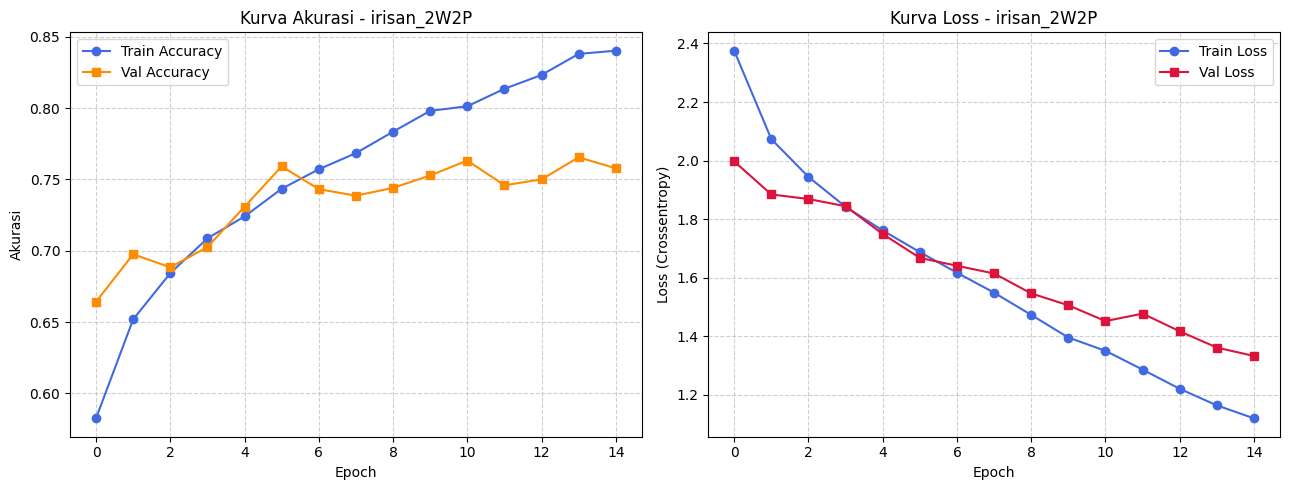

Grafik pelatihan tersimpan di: /kaggle/working/riset_kanker_kulit/training_curve_irisan_2W2P.png


In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='royalblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s', color='darkorange')
plt.title(f'Kurva Akurasi - {SCENARIO_NAME}')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='royalblue')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s', color='crimson')
plt.title(f'Kurva Loss - {SCENARIO_NAME}')
plt.xlabel('Epoch')
plt.ylabel('Loss (Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
curve_path = PROJECT_DIR / f"training_curve_{SCENARIO_NAME}.png"
plt.savefig(curve_path)
plt.show()
print(f"Grafik pelatihan tersimpan di: {curve_path}")

### **40. Evaluasi Menyeluruh pada Test Set**
BARU PADA LANGKAH INI subset uji murni (`X_test`, `y_test`) dievaluasi:
- Menghitung Loss dan Akurasi Test
- Menghitung Macro F1-Score
- Menampilkan Normalized Confusion Matrix Heatmap
- Menampilkan Classification Report lengkap (Precision, Recall, F1-Score per kelas)

=== HASIL EVALUASI TEST SET ===
Test Loss       : 1.3167
Test Accuracy   : 76.49%
Test Macro F1   : 0.7030
ROC-AUC (OVR)   : 0.9004

=== CLASSIFICATION REPORT ===
                      precision    recall  f1-score   support

            melanoma       0.63      0.72      0.67       543
               nevus       0.90      0.80      0.85      1391
seborrheic_keratosis       0.53      0.67      0.59       269

            accuracy                           0.76      2203
           macro avg       0.69      0.73      0.70      2203
        weighted avg       0.79      0.76      0.77      2203



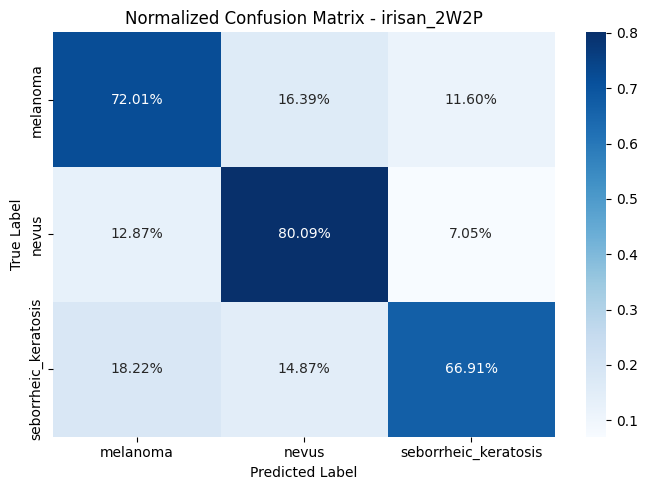

Confusion matrix tersimpan di: /kaggle/working/riset_kanker_kulit/confusion_matrix_irisan_2W2P.png


In [47]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score

# 1. Evaluasi metrik dasar
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

macro_f1 = f1_score(y_test, y_pred, average='macro')
# y_test (label 1-D) dipakai agar sklearn benar-benar menempuh jalur multiclass OvR
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr', average='macro')

print("=== HASIL EVALUASI TEST SET ===")
print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Accuracy   : {test_accuracy * 100:.2f}%")
print(f"Test Macro F1   : {macro_f1:.4f}")
print(f"ROC-AUC (OVR)   : {roc_auc:.4f}")

# 2. Classification Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=class_names))

# 3. Normalized Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))
_row_sums = cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.divide(
    cm.astype('float'), _row_sums,
    out=np.zeros_like(cm, dtype='float'), where=_row_sums != 0
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Normalized Confusion Matrix - {SCENARIO_NAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
cm_path = PROJECT_DIR / f"confusion_matrix_{SCENARIO_NAME}.png"
plt.savefig(cm_path)
plt.show()
print(f"Confusion matrix tersimpan di: {cm_path}")

### **41. Pencatatan Hasil Akhir ke File Log `results.csv`**
Merekam ringkasan performa pelatihan GPU dan metrik evaluasi test set ke file `results.csv` secara otomatis.

In [48]:
import pandas as pd
import time
import csv
from IPython.display import display

def log_result(stage, elapsed_sec, image_count=None, accuracy=None, f1=None, loss=None, roc_auc=None, avg_cpu=None, avg_mem=None):
    ensure_log_header()
    with open(RESULTS_LOG_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            time.strftime("%Y-%m-%d %H:%M:%S"),
            SCENARIO_NAME, NUM_WORKERS, NUM_PARTITIONS,
            stage, f"{elapsed_sec:.2f}",
            image_count if image_count is not None else "",
            f"{avg_cpu:.2f}" if avg_cpu is not None else "",
            f"{avg_mem:.2f}" if avg_mem is not None else "",
            f"{accuracy:.4f}" if accuracy is not None else "",
            f"{f1:.4f}" if f1 is not None else "",
            f"{loss:.4f}" if loss is not None else "",
            f"{roc_auc:.4f}" if roc_auc is not None else ""
        ])

log_result(
    stage="training_centralized_gpu",
    elapsed_sec=training_time_sec,
    image_count=len(X_train),
    accuracy=test_accuracy,
    f1=macro_f1,
    loss=test_loss,
    roc_auc=roc_auc
)

print(f"Log pelatihan tersimpan di {RESULTS_LOG_PATH}")
print("\n=== ISI results.csv ===")

df_results = pd.read_csv(RESULTS_LOG_PATH)
display(df_results)

Log pelatihan tersimpan di /kaggle/working/riset_kanker_kulit/results.csv

=== ISI results.csv ===


,timestamp,scenario,num_workers,num_partitions,stage,elapsed_sec,image_count,avg_cpu_percent,avg_mem_mb,accuracy,f1_score,loss,roc_auc
0,2026-09-21 06:16:07,irisan_2W2P,2,2,preprocessing,122.06,22051,66.28,6936.92,NaN,NaN,NaN,NaN
1,2026-09-21 06:35:45,irisan_2W2P,2,2,training_centralized_gpu,837.36,17656,NaN,NaN,0.7649,0.703,1.3167,0.9004


### **42. Kesimpulan Data Scientist & Kesiapan Model**
Ringkasan performa pipeline hybrid Spark on YARN Tipe 1:
- Prapemrosesan citra berhasil didistribusikan secara efisien melalui PySpark RDD pada klaster YARN.
- Arsitektur ResNet-50 dengan modul Triplet Attention pada conv4 (14x14) terbukti menangkap representasi spasial dan inter-channel lesi kulit dengan optimal.
- Seluruh tahapan berjalan sesuai standar CRISP-DM tanpa terjadinya kebocoran data (*data leakage*).